In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# Plot settings
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
production = pd.read_csv("Production_Crops_Livestock_E_All_Data.csv", low_memory=False)

population = pd.read_csv("Population_E_All_Data.csv", low_memory=False)

landuse = pd.read_csv("Inputs_LandUse_E_All_Data.csv", low_memory=False)

fertilizer = pd.read_csv("Inputs_FertilizersNutrient_E_All_Data.csv", low_memory=False)

foodbalance = pd.read_csv("FoodBalanceSheets_E_All_Data.csv", low_memory=False)

foodsecurity = pd.read_csv("Food_Security_Data_E_All_Data.csv", low_memory=False)

In [5]:
datasets = {
    "Production": production,
    "Population": population,
    "Land Use": landuse,
    "Fertilizer": fertilizer,
    "Food Balance": foodbalance,
    "Food Security": foodsecurity
}

for name, df in datasets.items():
    print("="*70)
    print(name)
    print("="*70)

    print("Shape:", df.shape)

    print("\nColumns")
    print(df.columns.tolist())

    print("\nFirst Five Rows")
    display(df.head())

    print("\nMissing Values")
    print(df.isnull().sum().head(20))

    print("\n")

Production
Shape: (78974, 201)

Columns
['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item Code (CPC)', 'Item', 'Element Code', 'Element', 'Unit', 'Y1961', 'Y1961F', 'Y1961N', 'Y1962', 'Y1962F', 'Y1962N', 'Y1963', 'Y1963F', 'Y1963N', 'Y1964', 'Y1964F', 'Y1964N', 'Y1965', 'Y1965F', 'Y1965N', 'Y1966', 'Y1966F', 'Y1966N', 'Y1967', 'Y1967F', 'Y1967N', 'Y1968', 'Y1968F', 'Y1968N', 'Y1969', 'Y1969F', 'Y1969N', 'Y1970', 'Y1970F', 'Y1970N', 'Y1971', 'Y1971F', 'Y1971N', 'Y1972', 'Y1972F', 'Y1972N', 'Y1973', 'Y1973F', 'Y1973N', 'Y1974', 'Y1974F', 'Y1974N', 'Y1975', 'Y1975F', 'Y1975N', 'Y1976', 'Y1976F', 'Y1976N', 'Y1977', 'Y1977F', 'Y1977N', 'Y1978', 'Y1978F', 'Y1978N', 'Y1979', 'Y1979F', 'Y1979N', 'Y1980', 'Y1980F', 'Y1980N', 'Y1981', 'Y1981F', 'Y1981N', 'Y1982', 'Y1982F', 'Y1982N', 'Y1983', 'Y1983F', 'Y1983N', 'Y1984', 'Y1984F', 'Y1984N', 'Y1985', 'Y1985F', 'Y1985N', 'Y1986', 'Y1986F', 'Y1986N', 'Y1987', 'Y1987F', 'Y1987N', 'Y1988', 'Y1988F', 'Y1988N', 'Y1989', 'Y1989F', 'Y1989N', 'Y1

,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,Y1961F,Y1961N,Y1962,Y1962F,Y1962N,Y1963,Y1963F,Y1963N,Y1964,Y1964F,Y1964N,Y1965,Y1965F,Y1965N,Y1966,Y1966F,Y1966N,Y1967,Y1967F,Y1967N,Y1968,Y1968F,Y1968N,Y1969,Y1969F,Y1969N,Y1970,Y1970F,Y1970N,Y1971,Y1971F,Y1971N,Y1972,Y1972F,Y1972N,Y1973,Y1973F,Y1973N,Y1974,Y1974F,Y1974N,Y1975,Y1975F,Y1975N,Y1976,Y1976F,Y1976N,Y1977,Y1977F,Y1977N,Y1978,Y1978F,Y1978N,Y1979,Y1979F,Y1979N,Y1980,Y1980F,Y1980N,Y1981,Y1981F,Y1981N,Y1982,Y1982F,Y1982N,Y1983,Y1983F,Y1983N,Y1984,Y1984F,Y1984N,Y1985,Y1985F,Y1985N,Y1986,Y1986F,Y1986N,Y1987,Y1987F,Y1987N,Y1988,Y1988F,Y1988N,Y1989,Y1989F,Y1989N,Y1990,Y1990F,Y1990N,Y1991,Y1991F,Y1991N,Y1992,Y1992F,Y1992N,Y1993,Y1993F,Y1993N,Y1994,Y1994F,Y1994N,Y1995,Y1995F,Y1995N,Y1996,Y1996F,Y1996N,Y1997,Y1997F,Y1997N,Y1998,Y1998F,Y1998N,Y1999,Y1999F,Y1999N,Y2000,Y2000F,Y2000N,Y2001,Y2001F,Y2001N,Y2002,Y2002F,Y2002N,Y2003,Y2003F,Y2003N,Y2004,Y2004F,Y2004N,Y2005,Y2005F,Y2005N,Y2006,Y2006F,Y2006N,Y2007,Y2007F,Y2007N,Y2008,Y2008F,Y2008N,Y2009,Y2009F,Y2009N,Y2010,Y2010F,Y2010N,Y2011,Y2011F,Y2011N,Y2012,Y2012F,Y2012N,Y2013,Y2013F,Y2013N,Y2014,Y2014F,Y2014N,Y2015,Y2015F,Y2015N,Y2016,Y2016F,Y2016N,Y2017,Y2017F,Y2017N,Y2018,Y2018F,Y2018N,Y2019,Y2019F,Y2019N,Y2020,Y2020F,Y2020N,Y2021,Y2021F,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N,Y2024,Y2024F,Y2024N
0,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5312,Area harvested,ha,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,E,NaN,5900.0,E,NaN,6000.0,E,NaN,6000.0,E,NaN,6000.0,E,NaN,5800.0,E,NaN,5800.0,E,NaN,5800.0,E,NaN,5700.0,E,NaN,5700.0,E,NaN,5600.0,E,NaN,5500.0,E,NaN,5500.0,E,NaN,5400.0,E,NaN,5400.0,E,NaN,6037.0,E,NaN,5500.0,A,NaN,5500.0,A,NaN,5500.0,A,NaN,5500.0,A,NaN,5500.0,A,NaN,5500.0,A,NaN,5500.0,A,NaN,5500.0,A,NaN,5500.0,A,NaN,7000.0,E,NaN,9000.0,E,NaN,5500.00,A,NaN,5700.0,A,NaN,12000.0,X,Unofficial figure,11768.0,I,NaN,12000.0,A,NaN,12000.0,A,NaN,12000.0,A,NaN,11029.0,A,NaN,11210.0,A,NaN,13469.0,A,NaN,13490.0,A,NaN,14114.0,A,NaN,13703.0,A,NaN,14676.0,A,NaN,19481.0,A,NaN,19793.0,A,NaN,20053.0,A,NaN,29203.0,A,NaN,22134.0,A,NaN,36862.0,A,NaN,36462.0,A,NaN,37000.0,A,NaN,39794.00,I,NaN
1,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5412,Yield,kg/ha,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1661.0,E,NaN,1500.0,E,NaN,2000.0,E,NaN,1750.0,E,NaN,1706.9,E,NaN,1379.3,E,NaN,1896.6,E,NaN,1701.8,E,NaN,1842.1,E,NaN,1607.1,E,NaN,1818.2,E,NaN,1636.4,E,NaN,1666.7,E,NaN,1629.6,E,NaN,1573.6,E,NaN,1636.4,A,NaN,1800.0,A,NaN,1636.4,A,NaN,1636.4,A,NaN,1636.4,A,NaN,1636.4,A,NaN,1636.4,A,NaN,1636.4,A,NaN,2000.0,E,NaN,1714.3,E,NaN,1666.7,E,NaN,2140.70,E,NaN,2456.1,E,NaN,1225.0,X,NaN,1328.1,E,NaN,1666.7,A,NaN,2623.4,A,NaN,3500.0,A,NaN,3915.4,E,NaN,4995.5,A,NaN,4500.0,A,NaN,4596.0,A,NaN,2991.0,A,NaN,1999.6,A,NaN,1652.1,A,NaN,1685.9,A,NaN,1378.8,A,NaN,1716.1,A,NaN,1308.3,A,NaN,1775.9,A,NaN,1743.2,A,NaN,1742.0,A,NaN,1810.8,A,NaN,1741.90,E,NaN
2,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5510,Production,t,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,A,NaN,0.0,E,NaN,9800.0,E,NaN,9000.0,E,NaN,12000.0,E,NaN,10500.0,E,NaN,9900.0,E,NaN,8000.0,E,NaN,11000.0,E,NaN,9700.0,E,NaN,10500.0,E,NaN,9000.0,E,NaN,10000.0,E,NaN,9000.0,E,NaN,9000.0,E,NaN,8800.0,E,NaN,9500.0,E,NaN,9000.0,A,NaN,9900.0,A,NaN,9000.0,A,NaN,9000.0,A,NaN,9000.0,A,NaN,9000.0,A,NaN,9000.0,A,NaN,9000.0,A,NaN,11000.0,E,NaN,12000.0,E,NaN,15000.0,E,NaN,11773.99,I,NaN,14000.0,X,Unofficial figure,14700.0,X,Unofficial figure,15630.0,X,Unofficial figure,20000.0,A,NaN,31481.0,A,NaN,42000.0,A,NaN,43183.0,X,Unofficial figure,56000.0,A,NaN,60611.0,A,NaN,62000.0,A,NaN,42215.0,A,NaN,27400.0,A,NaN,24246.0,A,NaN,32843.0,A,NaN,27291.0,A,N


Missing Values
Area Code              0
Area Code (M49)        0
Area                   0
Item Code              0
Item Code (CPC)        0
Item                   0
Element Code           0
Element                0
Unit                   0
Y1961              21656
Y1961F             19882
Y1961N             78147
Y1962              21649
Y1962F             19872
Y1962N             78140
Y1963              21650
Y1963F             19873
Y1963N             78170
Y1964              21635
Y1964F             19859
dtype: int64


Population
Shape: (1385, 461)

Columns
['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item', 'Element Code', 'Element', 'Unit', 'Y1950', 'Y1950F', 'Y1950N', 'Y1951', 'Y1951F', 'Y1951N', 'Y1952', 'Y1952F', 'Y1952N', 'Y1953', 'Y1953F', 'Y1953N', 'Y1954', 'Y1954F', 'Y1954N', 'Y1955', 'Y1955F', 'Y1955N', 'Y1956', 'Y1956F', 'Y1956N', 'Y1957', 'Y1957F', 'Y1957N', 'Y1958', 'Y1958F', 'Y1958N', 'Y1959', 'Y1959F', 'Y1959N', 'Y1960', 'Y1960F', 'Y1960N', 'Y1961', 'Y196

,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Unit,Y1950,Y1950F,Y1950N,Y1951,Y1951F,Y1951N,Y1952,Y1952F,Y1952N,Y1953,Y1953F,Y1953N,Y1954,Y1954F,Y1954N,Y1955,Y1955F,Y1955N,Y1956,Y1956F,Y1956N,Y1957,Y1957F,Y1957N,Y1958,Y1958F,Y1958N,Y1959,Y1959F,Y1959N,Y1960,Y1960F,Y1960N,Y1961,Y1961F,Y1961N,Y1962,Y1962F,Y1962N,Y1963,Y1963F,Y1963N,Y1964,Y1964F,Y1964N,Y1965,Y1965F,Y1965N,Y1966,Y1966F,Y1966N,Y1967,Y1967F,Y1967N,Y1968,Y1968F,Y1968N,Y1969,Y1969F,Y1969N,Y1970,Y1970F,Y1970N,Y1971,Y1971F,Y1971N,Y1972,Y1972F,Y1972N,Y1973,Y1973F,Y1973N,Y1974,Y1974F,Y1974N,Y1975,Y1975F,Y1975N,Y1976,Y1976F,Y1976N,Y1977,Y1977F,Y1977N,Y1978,Y1978F,Y1978N,Y1979,Y1979F,Y1979N,Y1980,Y1980F,Y1980N,Y1981,Y1981F,Y1981N,Y1982,Y1982F,Y1982N,Y1983,Y1983F,Y1983N,Y1984,Y1984F,Y1984N,Y1985,Y1985F,Y1985N,Y1986,Y1986F,Y1986N,Y1987,Y1987F,Y1987N,Y1988,Y1988F,Y1988N,Y1989,Y1989F,Y1989N,Y1990,Y1990F,Y1990N,Y1991,Y1991F,Y1991N,Y1992,Y1992F,Y1992N,Y1993,Y1993F,Y1993N,Y1994,Y1994F,Y1994N,Y1995,Y1995F,Y1995N,Y1996,Y1996F,Y1996N,Y1997,Y1997F,Y1997N,Y1998,Y1998F,Y1998N,Y1999,Y1999F,Y1999N,Y2000,Y2000F,Y2000N,Y2001,Y2001F,Y2001N,Y2002,Y2002F,Y2002N,Y2003,Y2003F,Y2003N,Y2004,Y2004F,Y2004N,Y2005,Y2005F,Y2005N,Y2006,Y2006F,Y2006N,Y2007,Y2007F,Y2007N,Y2008,Y2008F,Y2008N,Y2009,Y2009F,Y2009N,Y2010,Y2010F,Y2010N,Y2011,Y2011F,Y2011N,Y2012,Y2012F,Y2012N,Y2013,Y2013F,Y2013N,Y2014,Y2014F,Y2014N,Y2015,Y2015F,Y2015N,Y2016,Y2016F,Y2016N,Y2017,Y2017F,Y2017N,Y2018,Y2018F,Y2018N,Y2019,Y2019F,Y2019N,Y2020,Y2020F,Y2020N,Y2021,Y2021F,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N,Y2024,Y2024F,Y2024N,Y2025,Y2025F,Y2025N,Y2026,Y2026F,Y2026N,Y2027,Y2027F,Y2027N,Y2028,Y2028F,Y2028N,Y2029,Y2029F,Y2029N,Y2030,Y2030F,Y2030N,Y2031,Y2031F,Y2031N,Y2032,Y2032F,Y2032N,Y2033,Y2033F,Y2033N,Y2034,Y2034F,Y2034N,Y2035,Y2035F,Y2035N,Y2036,Y2036F,Y2036N,Y2037,Y2037F,Y2037N,Y2038,Y2038F,Y2038N,Y2039,Y2039F,Y2039N,Y2040,Y2040F,Y2040N,Y2041,Y2041F,Y2041N,Y2042,Y2042F,Y2042N,Y2043,Y2043F,Y2043N,Y2044,Y2044F,Y2044N,Y2045,Y2045F,Y2045N,Y2046,Y2046F,Y2046N,Y2047,Y2047F,Y2047N,Y2048,Y2048F,Y2048N,Y2049,Y2049F,Y2049N,Y2050,Y2050F,Y2050N,Y2051,Y2051F,Y2051N,Y2052,Y2052F,Y2052N,Y2053,Y2053F,Y2053N,Y2054,Y2054F,Y2054N,Y2055,Y2055F,Y2055N,Y2056,Y2056F,Y2056N,Y2057,Y2057F,Y2057N,Y2058,Y2058F,Y2058N,Y2059,Y2059F,Y2059N,Y2060,Y2060F,Y2060N,Y2061,Y2061F,Y2061N,Y2062,Y2062F,Y2062N,Y2063,Y2063F,Y2063N,Y2064,Y2064F,Y2064N,Y2065,Y2065F,Y2065N,Y2066,Y2066F,Y2066N,Y2067,Y2067F,Y2067N,Y2068,Y2068F,Y2068N,Y2069,Y2069F,Y2069N,Y2070,Y2070F,Y2070N,Y2071,Y2071F,Y2071N,Y2072,Y2072F,Y2072N,Y2073,Y2073F,Y2073N,Y2074,Y2074F,Y2074N,Y2075,Y2075F,Y2075N,Y2076,Y2076F,Y2076N,Y2077,Y2077F,Y2077N,Y2078,Y2078F,Y2078N,Y2079,Y2079F,Y2079N,Y2080,Y2080F,Y2080N,Y2081,Y2081F,Y2081N,Y2082,Y2082F,Y2082N,Y2083,Y2083F,Y2083N,Y2084,Y2084F,Y2084N,Y2085,Y2085F,Y2085N,Y2086,Y2086F,Y2086N,Y2087,Y2087F,Y2087N,Y2088,Y2088F,Y2088N,Y2089,Y2089F,Y2089N,Y2090,Y2090F,Y2090N,Y2091,Y2091F,Y2091N,Y2092,Y2092F,Y2092N,Y2093,Y2093F,Y2093N,Y2094,Y2094F,Y2094N,Y2095,Y2095F,Y2095N,Y2096,Y2096F,Y2096N,Y2097,Y2097F,Y2097N,Y2098,Y2098F,Y2098N,Y2099,Y2099F,Y2099N,Y2100,Y2100F,Y2100N
0,2,'004,Afghanistan,3010,Population - Est. & Proj.,511,Total Population - Both sexes,1000 No,7776.176,X,NaN,7879.339,X,NaN,7987.783,X,NaN,8096.698,X,NaN,8207.950,X,NaN,8326.979,X,NaN,8454.301,X,NaN,8588.335,X,NaN,8723.401,X,NaN,8869.270,X,NaN,9035.043,X,NaN,9214.083,X,NaN,9404.406,X,NaN,9604.487,X,NaN,9814.318,X,NaN,10036.008,X,NaN,10266.395,X,NaN,10505.959,X,NaN,10756.922,X,NaN,11017.409,X,NaN,11290.128,X,NaN,11567.667,X,NaN,11853.696,X,NaN,12157.999,X,NaN,12469.127,X,NaN,12773.954,X,NaN,13059.851,X,NaN,13340.756,X,NaN,13611.441,X,NaN,13655.567,X,NaN,13169.311,X,NaN,11937.581,X,NaN,10991.378,X,NaN,10917.982,X,NaN,11190.221,X,NaN,11426.852,X,NaN,11420.074,X,NaN,11387.818,X,NaN,11523.298,X,NaN,11874.088,X,NaN,12045.660,X,NaN,12238.879,X,NaN,13278.974,X,NaN,14943.172,X,NaN,16250.794,X,NaN,17065.836,X,NaN,17763.266,X,NaN,18452.091,X,NaN,19159.996,X,NaN,19887.785,X,NaN,20130.327,X,NaN,20284.307,X,


Missing Values
Area Code             0
Area Code (M49)       0
Area                  0
Item Code             0
Item                  0
Element Code          0
Element               0
Unit                  0
Y1950               196
Y1950F              196
Y1950N             1385
Y1951               196
Y1951F              196
Y1951N             1385
Y1952               196
Y1952F              196
Y1952N             1385
Y1953               196
Y1953F              196
Y1953N             1385
dtype: int64


Land Use
Shape: (10158, 203)

Columns
['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item', 'Element Code', 'Element', 'Unit', 'Y1961', 'Y1961F', 'Y1961N', 'Y1962', 'Y1962F', 'Y1962N', 'Y1963', 'Y1963F', 'Y1963N', 'Y1964', 'Y1964F', 'Y1964N', 'Y1965', 'Y1965F', 'Y1965N', 'Y1966', 'Y1966F', 'Y1966N', 'Y1967', 'Y1967F', 'Y1967N', 'Y1968', 'Y1968F', 'Y1968N', 'Y1969', 'Y1969F', 'Y1969N', 'Y1970', 'Y1970F', 'Y1970N', 'Y1971', 'Y1971F', 'Y1971N', 'Y1972', 'Y1972F', 'Y1972N', 'Y1973

...


Missing Values
Area Code             0
Area Code (M49)       0
Area                  0
Item Code             0
Item                  0
Element Code          0
Element               0
Unit                  0
Y1961              2752
Y1961F             2752
Y1961N             4623
Y1962              2753
Y1962F             2753
Y1962N             4657
Y1963              2727
Y1963F             2727
Y1963N             4663
Y1964              2695
Y1964F             2695
Y1964N             4484
dtype: int64


Food Balance
Shape: (373670, 51)

Columns
['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item Code (FBS)', 'Item', 'Element Code', 'Element', 'Unit', 'Y2010', 'Y2010F', 'Y2010N', 'Y2011', 'Y2011F', 'Y2011N', 'Y2012', 'Y2012F', 'Y2012N', 'Y2013', 'Y2013F', 'Y2013N', 'Y2014', 'Y2014F', 'Y2014N', 'Y2015', 'Y2015F', 'Y2015N', 'Y2016', 'Y2016F', 'Y2016N', 'Y2017', 'Y2017F', 'Y2017N', 'Y2018', 'Y2018F', 'Y2018N', 'Y2019', 'Y2019F', 'Y2019N', 'Y2020', 'Y2020F', 'Y2020N', 'Y2021', 'Y2

,Area Code,Area Code (M49),Area,Item Code,Item Code (FBS),Item,Element Code,Element,Unit,Y2010,Y2010F,Y2010N,Y2011,Y2011F,Y2011N,Y2012,Y2012F,Y2012N,Y2013,Y2013F,Y2013N,Y2014,Y2014F,Y2014N,Y2015,Y2015F,Y2015N,Y2016,Y2016F,Y2016N,Y2017,Y2017F,Y2017N,Y2018,Y2018F,Y2018N,Y2019,Y2019F,Y2019N,Y2020,Y2020F,Y2020N,Y2021,Y2021F,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N
0,2,'004,Afghanistan,2501,'S2501,Population,511,Total Population - Both sexes,1000 No,28284.09,X,NaN,29347.71,X,NaN,30560.03,X,NaN,31622.70,X,NaN,32792.52,X,NaN,33831.76,X,NaN,34700.61,X,NaN,35688.93,X,NaN,36743.04,X,NaN,37856.12,X,NaN,39068.98,X,NaN,40000.41,X,NaN,40578.84,X,NaN,41454.76,X,NaN
1,2,'004,Afghanistan,2901,'S2901,Grand Total,664,Food supply (kcal/capita/day),kcal/cap/d,2200.21,E,NaN,2171.86,E,NaN,2165.88,E,NaN,2205.33,E,NaN,2270.45,E,NaN,2251.27,E,NaN,2240.71,E,NaN,2307.21,E,NaN,2261.79,E,NaN,2223.10,E,NaN,2259.95,E,NaN,2244.73,E,NaN,2268.63,E,NaN,2314.63,E,NaN
2,2,'004,Afghanistan,2901,'S2901,Grand Total,661,Food supply (kcal),million Kcal,22714261.33,E,NaN,23264732.28,E,NaN,24159167.28,E,NaN,25454589.34,E,NaN,27175651.99,E,NaN,27799992.36,E,NaN,28380157.97,E,NaN,30054816.91,E,NaN,30333352.71,E,NaN,30717599.09,E,NaN,32227343.15,E,NaN,32773345.26,E,NaN,33601287.96,E,NaN,35022662.41,E,NaN
3,2,'004,Afghanistan,2901,'S2901,Grand Total,674,Protein supply quantity (g/capita/day),g/cap/d,65.54,E,NaN,63.74,E,NaN,62.67,E,NaN,63.24,E,NaN,65.55,E,NaN,63.93,E,NaN,64.82,E,NaN,65.33,E,NaN,62.84,E,NaN,60.84,E,NaN,63.21,E,NaN,61.36,E,NaN,61.55,E,NaN,62.58,E,NaN
4,2,'004,Afghanistan,2901,'S2901,Grand Total,671,Protein supply quantity (t),t,676666.08,E,NaN,682796.03,E,NaN,699046.85,E,NaN,729923.88,E,NaN,784625.74,E,NaN,789385.73,E,NaN,820992.96,E,NaN,851041.58,E,NaN,842749.06,E,NaN,840696.76,E,NaN,901388.20,E,NaN,895904.37,E,NaN,911681.15,E,NaN,946916.80,E,NaN



Missing Values
Area Code               0
Area Code (M49)         0
Area                    0
Item Code               0
Item Code (FBS)         0
Item                    0
Element Code            0
Element                 0
Unit                    0
Y2010               34084
Y2010F              34084
Y2010N             373670
Y2011               33881
Y2011F              33881
Y2011N             373670
Y2012               33257
Y2012F              33257
Y2012N             373670
Y2013               33066
Y2013F              33066
dtype: int64


Food Security
Shape: (19373, 155)

Columns
['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item', 'Element Code', 'Element', 'Unit', 'Y2000', 'Y2000F', 'Y2000N', 'Y20002002', 'Y20002002F', 'Y20002002N', 'Y2001', 'Y2001F', 'Y2001N', 'Y20012003', 'Y20012003F', 'Y20012003N', 'Y2002', 'Y2002F', 'Y2002N', 'Y20022004', 'Y20022004F', 'Y20022004N', 'Y2003', 'Y2003F', 'Y2003N', 'Y20032005', 'Y20032005F', 'Y20032005N', 'Y2004', 'Y2004F', 'Y2004N', 

,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Unit,Y2000,Y2000F,Y2000N,Y20002002,Y20002002F,Y20002002N,Y2001,Y2001F,Y2001N,Y20012003,Y20012003F,Y20012003N,Y2002,Y2002F,Y2002N,Y20022004,Y20022004F,Y20022004N,Y2003,Y2003F,Y2003N,Y20032005,Y20032005F,Y20032005N,Y2004,Y2004F,Y2004N,Y20042006,Y20042006F,Y20042006N,Y2005,Y2005F,Y2005N,Y20052007,Y20052007F,Y20052007N,Y2006,Y2006F,Y2006N,Y20062008,Y20062008F,Y20062008N,Y2007,Y2007F,Y2007N,Y20072009,Y20072009F,Y20072009N,Y2008,Y2008F,Y2008N,Y20082010,Y20082010F,Y20082010N,Y2009,Y2009F,Y2009N,Y20092011,Y20092011F,Y20092011N,Y2010,Y2010F,Y2010N,Y20102012,Y20102012F,Y20102012N,Y2011,Y2011F,Y2011N,Y20112013,Y20112013F,Y20112013N,Y2012,Y2012F,Y2012N,Y20122014,Y20122014F,Y20122014N,Y2013,Y2013F,Y2013N,Y20132015,Y20132015F,Y20132015N,Y2014,Y2014F,Y2014N,Y20142016,Y20142016F,Y20142016N,Y2015,Y2015F,Y2015N,Y20152017,Y20152017F,Y20152017N,Y2016,Y2016F,Y2016N,Y20162018,Y20162018F,Y20162018N,Y2017,Y2017F,Y2017N,Y20172019,Y20172019F,Y20172019N,Y2018,Y2018F,Y2018N,Y20182020,Y20182020F,Y20182020N,Y2019,Y2019F,Y2019N,Y20192021,Y20192021F,Y20192021N,Y2020,Y2020F,Y2020N,Y20202022,Y20202022F,Y20202022N,Y2021,Y2021F,Y2021N,Y20212023,Y20212023F,Y20212023N,Y2022,Y2022F,Y2022N,Y20222024,Y20222024F,Y20222024N,Y2023,Y2023F,Y2023N,Y2024,Y2024F,Y2024N,Y2025,Y2025F,Y2025N
0,2,'004,Afghanistan,21010,Average dietary energy supply adequacy (percen...,6121,Value,%,NaN,NaN,NaN,87,E,NaN,NaN,NaN,NaN,88,E,NaN,NaN,NaN,NaN,91,E,NaN,NaN,NaN,NaN,93,E,NaN,NaN,NaN,NaN,95,E,NaN,NaN,NaN,NaN,97,E,NaN,NaN,NaN,NaN,99,E,NaN,NaN,NaN,NaN,102,E,NaN,NaN,NaN,NaN,104,E,NaN,NaN,NaN,NaN,105,E,NaN,NaN,NaN,NaN,105,E,NaN,NaN,NaN,NaN,104,E,NaN,NaN,NaN,NaN,106,E,NaN,NaN,NaN,NaN,107,E,NaN,NaN,NaN,NaN,107,E,NaN,NaN,NaN,NaN,107,E,NaN,NaN,NaN,NaN,107,E,NaN,NaN,NaN,NaN,107,E,NaN,NaN,NaN,NaN,106,E,NaN,NaN,NaN,NaN,105,E,NaN,NaN,NaN,NaN,106,E,NaN,NaN,NaN,NaN,106,E,NaN,NaN,NaN,NaN,107,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,'004,Afghanistan,220001,Dietary energy supply used in the estimation o...,6128,Value,kcal/cap/d,NaN,NaN,NaN,NaN,NaN,NaN,1716,E,NaN,NaN,NaN,NaN,1794,E,NaN,NaN,NaN,NaN,1847,E,NaN,NaN,NaN,NaN,1897,E,NaN,NaN,NaN,NaN,1948,E,NaN,NaN,NaN,NaN,1998,E,NaN,NaN,NaN,NaN,2049,E,NaN,NaN,NaN,NaN,2099,E,NaN,NaN,NaN,NaN,2150,E,NaN,NaN,NaN,NaN,2200,E,NaN,NaN,NaN,NaN,2172,E,NaN,NaN,NaN,NaN,2166,E,NaN,NaN,NaN,NaN,2205,E,NaN,NaN,NaN,NaN,2270,E,NaN,NaN,NaN,NaN,2251,E,NaN,NaN,NaN,NaN,2241,E,NaN,NaN,NaN,NaN,2307,E,NaN,NaN,NaN,NaN,2262,E,NaN,NaN,NaN,NaN,2223,E,NaN,NaN,NaN,NaN,2260,E,NaN,NaN,NaN,NaN,2245,E,NaN,NaN,NaN,NaN,2269,E,NaN,NaN,NaN,NaN,2315,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,'004,Afghanistan,22000,Dietary energy supply used in the estimation o...,6128,Value,kcal/cap/d,NaN,NaN,NaN,1762,E,NaN,NaN,NaN,NaN,1788,E,NaN,NaN,NaN,NaN,1848,E,NaN,NaN,NaN,NaN,1898,E,NaN,NaN,NaN,NaN,1949,E,NaN,NaN,NaN,NaN,1999,E,NaN,NaN,NaN,NaN,2049,E,NaN,NaN,NaN,NaN,2100,E,NaN,NaN,NaN,NaN,2150,E,NaN,NaN,NaN,NaN,2174,E,NaN,NaN,NaN,NaN,2179,E,NaN,NaN,NaN,NaN,2181,E,NaN,NaN,NaN,NaN,2215,E,NaN,NaN,NaN,NaN,2243,E,NaN,NaN,NaN,NaN,2254,E,NaN,NaN,NaN,NaN,2267,E,NaN,NaN,NaN,NaN,2270,E,NaN,NaN,NaN,NaN,2263,E,NaN,NaN,NaN,NaN,2248,E,NaN,NaN,NaN,NaN,2243,E,NaN,NaN,NaN,NaN,2258,E,NaN,NaN,NaN,NaN,2277,E,NaN,NaN,NaN,NaN,2300,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,'004,Afghanistan,21012,Share of dietary energy supply derived from ce...,6121,Value,%,NaN,NaN,NaN,77,E,NaN,NaN,NaN,NaN,78,E,NaN,NaN,NaN,NaN,78,E,NaN,NaN,NaN,NaN,77,E,NaN,NaN,NaN,NaN,76,E,NaN,NaN,NaN,NaN,77,E,NaN,NaN,NaN,NaN,78,E,NaN,NaN,NaN,NaN,78,E,NaN,NaN,NaN,NaN,77,E,NaN,NaN,NaN,NaN,76,E,NaN,NaN,NaN,NaN,74,E,NaN,NaN,NaN,NaN,73,E,NaN,NaN,NaN,NaN,71,E,NaN,NaN,NaN,NaN,71,E,NaN,NaN,NaN,NaN,71,E,NaN,NaN,NaN,NaN,71,E,NaN,NaN,NaN,NaN,71,E,NaN,NaN,NaN,NaN,70,E,NaN,NaN,NaN,NaN,70,E,NaN,NaN,NaN,NaN,70,E,NaN,NaN,NaN,NaN,71,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,'004,Afghanistan,21013,Average protein supply (g/cap/day) (3-year ave...,6123,Value,g/cap/d,NaN,Na


Missing Values
Area Code              0
Area Code (M49)        0
Area                   0
Item Code              0
Item                   0
Element Code           0
Element                0
Unit                 196
Y2000              14883
Y2000F             14873
Y2000N             19327
Y20002002          17050
Y20002002F         16934
Y20002002N         19373
Y2001              14685
Y2001F             14675
Y2001N             19327
Y20012003          17050
Y20012003F         16934
Y20012003N         19373
dtype: int64




In [7]:
for name, df in datasets.items():

    print("="*60)
    print(name)
    print("="*60)

    display(df.describe(include="all").T.head(20))

Production


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area Code,78974.0,NaN,NaN,NaN,1324.567541,2202.488084,1.0,89.0,170.0,272.0,5817.0
Area Code (M49),78974,244,'001,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,78974,244,World,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Code,78974.0,NaN,NaN,NaN,867.966331,1467.460908,15.0,358.0,587.0,1037.0,17530.0
Item Code (CPC),78974,301,'0231,1194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item,78974,301,"Hen eggs in shell, fresh",1194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Element Code,78974.0,NaN,NaN,NaN,5409.061843,101.349759,5111.0,5312.0,5412.0,5510.0,5513.0
Element,78974,8,Production,30772,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit,78974,10,t,30453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Y1961,57318.0,NaN,NaN,NaN,1514904.056254,15874504.13034,0.0,703.0,6450.8,64327.435,1342210249.0


Population


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area Code,1385.0,NaN,NaN,NaN,778.425993,1723.180387,1.0,80.0,154.0,226.0,5817.0
Area Code (M49),1385,279,'004,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,1385,279,Afghanistan,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Code,1385.0,NaN,NaN,NaN,3010.0,0.0,3010.0,3010.0,3010.0,3010.0,3010.0
Item,1385,1,Population - Est. & Proj.,1385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Element Code,1385.0,NaN,NaN,NaN,529.6,21.803285,511.0,512.0,513.0,551.0,561.0
Element,1385,5,Total Population - Both sexes,277,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit,1385,1,1000 No,1385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Y1950,1189.0,NaN,NaN,NaN,29374.566811,134386.016528,0.0,71.518,1278.881,7596.53,2493091.968
Y1950F,1189,2,X,1162,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Land Use


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area Code,5287.0,NaN,NaN,NaN,2914.038207,10390.39208,1.0,75.0,154.0,231.0,58170.0
Area Code (M49),5287,281,'004,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,5287,281,Afghanistan,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Code,5287.0,NaN,NaN,NaN,3102.999054,0.81638,3102.0,3102.0,3103.0,3104.0,3104.0
Item,5287,3,Nutrient nitrogen N (total),1764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Element Code,5287.0,NaN,NaN,NaN,5398.014186,282.388777,5157.0,5159.0,5173.0,5610.0,5910.0
Element,5287,7,Import quantity,830,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit,5287,4,t,3097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Y1961,2535.0,NaN,NaN,NaN,143145.195116,747989.940327,0.0,2.17,26.47,10000.0,12937059.0
Y1961F,2535,4,E,1569,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Food Balance


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area Code,373670.0,NaN,NaN,NaN,1098.324093,2038.777014,1.0,86.0,155.0,233.0,5817.0
Area Code (M49),373670,213,'001,2226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,373670,213,World,2226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Code,373670.0,NaN,NaN,NaN,2687.417026,145.414542,2501.0,2563.0,2633.0,2769.0,2961.0
Item Code (FBS),373670,123,'S2905,4082,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item,373670,120,Milk - Excluding Butter,7568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Element Code,373670.0,NaN,NaN,NaN,3299.376886,2332.958907,511.0,671.0,5123.0,5301.0,5911.0
Element,373670,21,Domestic supply quantity,24646,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit,373670,7,1000 t,209865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Y2010,339586.0,NaN,NaN,NaN,417867.974982,23159311.5176,-33865.0,0.0,3.0,125.0,7165321578.45


Food Security


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area Code,19373.0,NaN,NaN,NaN,1610.114851,2452.046701,1.0,95.0,178.0,5102.0,9011.0
Area Code (M49),19373,249,'753,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,19373,249,Eastern Asia and South-eastern Asia,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Code,19373,69,210071F,747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item,19373,69,Number of severely food insecure female adults...,747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Element Code,19373.0,NaN,NaN,NaN,27744.528571,26919.414302,6121.0,6121.0,6132.0,61212.0,61322.0
Element,19373,3,Value,11777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit,19177,7,%,9956,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Y2000,4490,1419,<0.1,432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Y2000F,4500,4,X,3639,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
for name, df in datasets.items():

    print("="*70)
    print(name)
    print("="*70)

    df.info()

Production
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78974 entries, 0 to 78973
Columns: 201 entries, Area Code to Y2024N
dtypes: float64(64), int64(3), object(134)
memory usage: 121.1+ MB
Population
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Columns: 461 entries, Area Code to Y2100N
dtypes: float64(302), int64(3), object(156)
memory usage: 4.9+ MB
Land Use
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10158 entries, 0 to 10157
Columns: 203 entries, Area Code to Y2025N
dtypes: float64(130), int64(3), object(70)
memory usage: 15.7+ MB
Fertilizer
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5287 entries, 0 to 5286
Columns: 197 entries, Area Code to Y2023N
dtypes: float64(63), int64(3), object(131)
memory usage: 7.9+ MB
Food Balance
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373670 entries, 0 to 373669
Data columns (total 51 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Are

In [11]:
for name, df in datasets.items():

    duplicates = df.duplicated().sum()

    print(f"{name}: {duplicates} duplicate rows")

Production: 0 duplicate rows
Population: 0 duplicate rows
Land Use: 0 duplicate rows
Fertilizer: 0 duplicate rows
Food Balance: 0 duplicate rows
Food Security: 0 duplicate rows


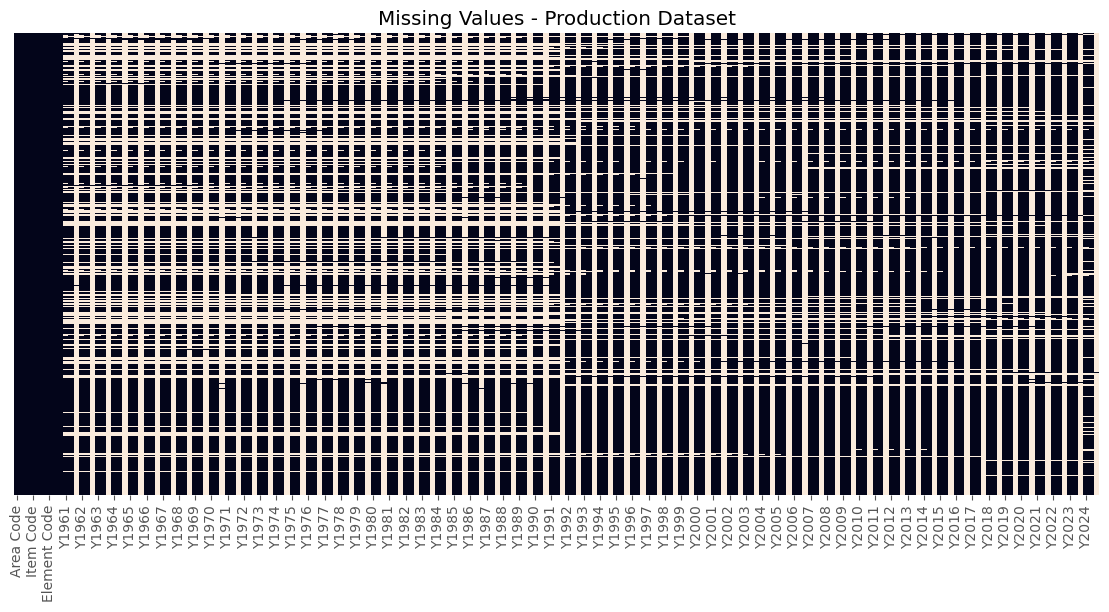

In [13]:
plt.figure(figsize=(14,6))

sns.heatmap(production.isnull(),
            cbar=False,
            yticklabels=False)

plt.title("Missing Values - Production Dataset")

plt.show()

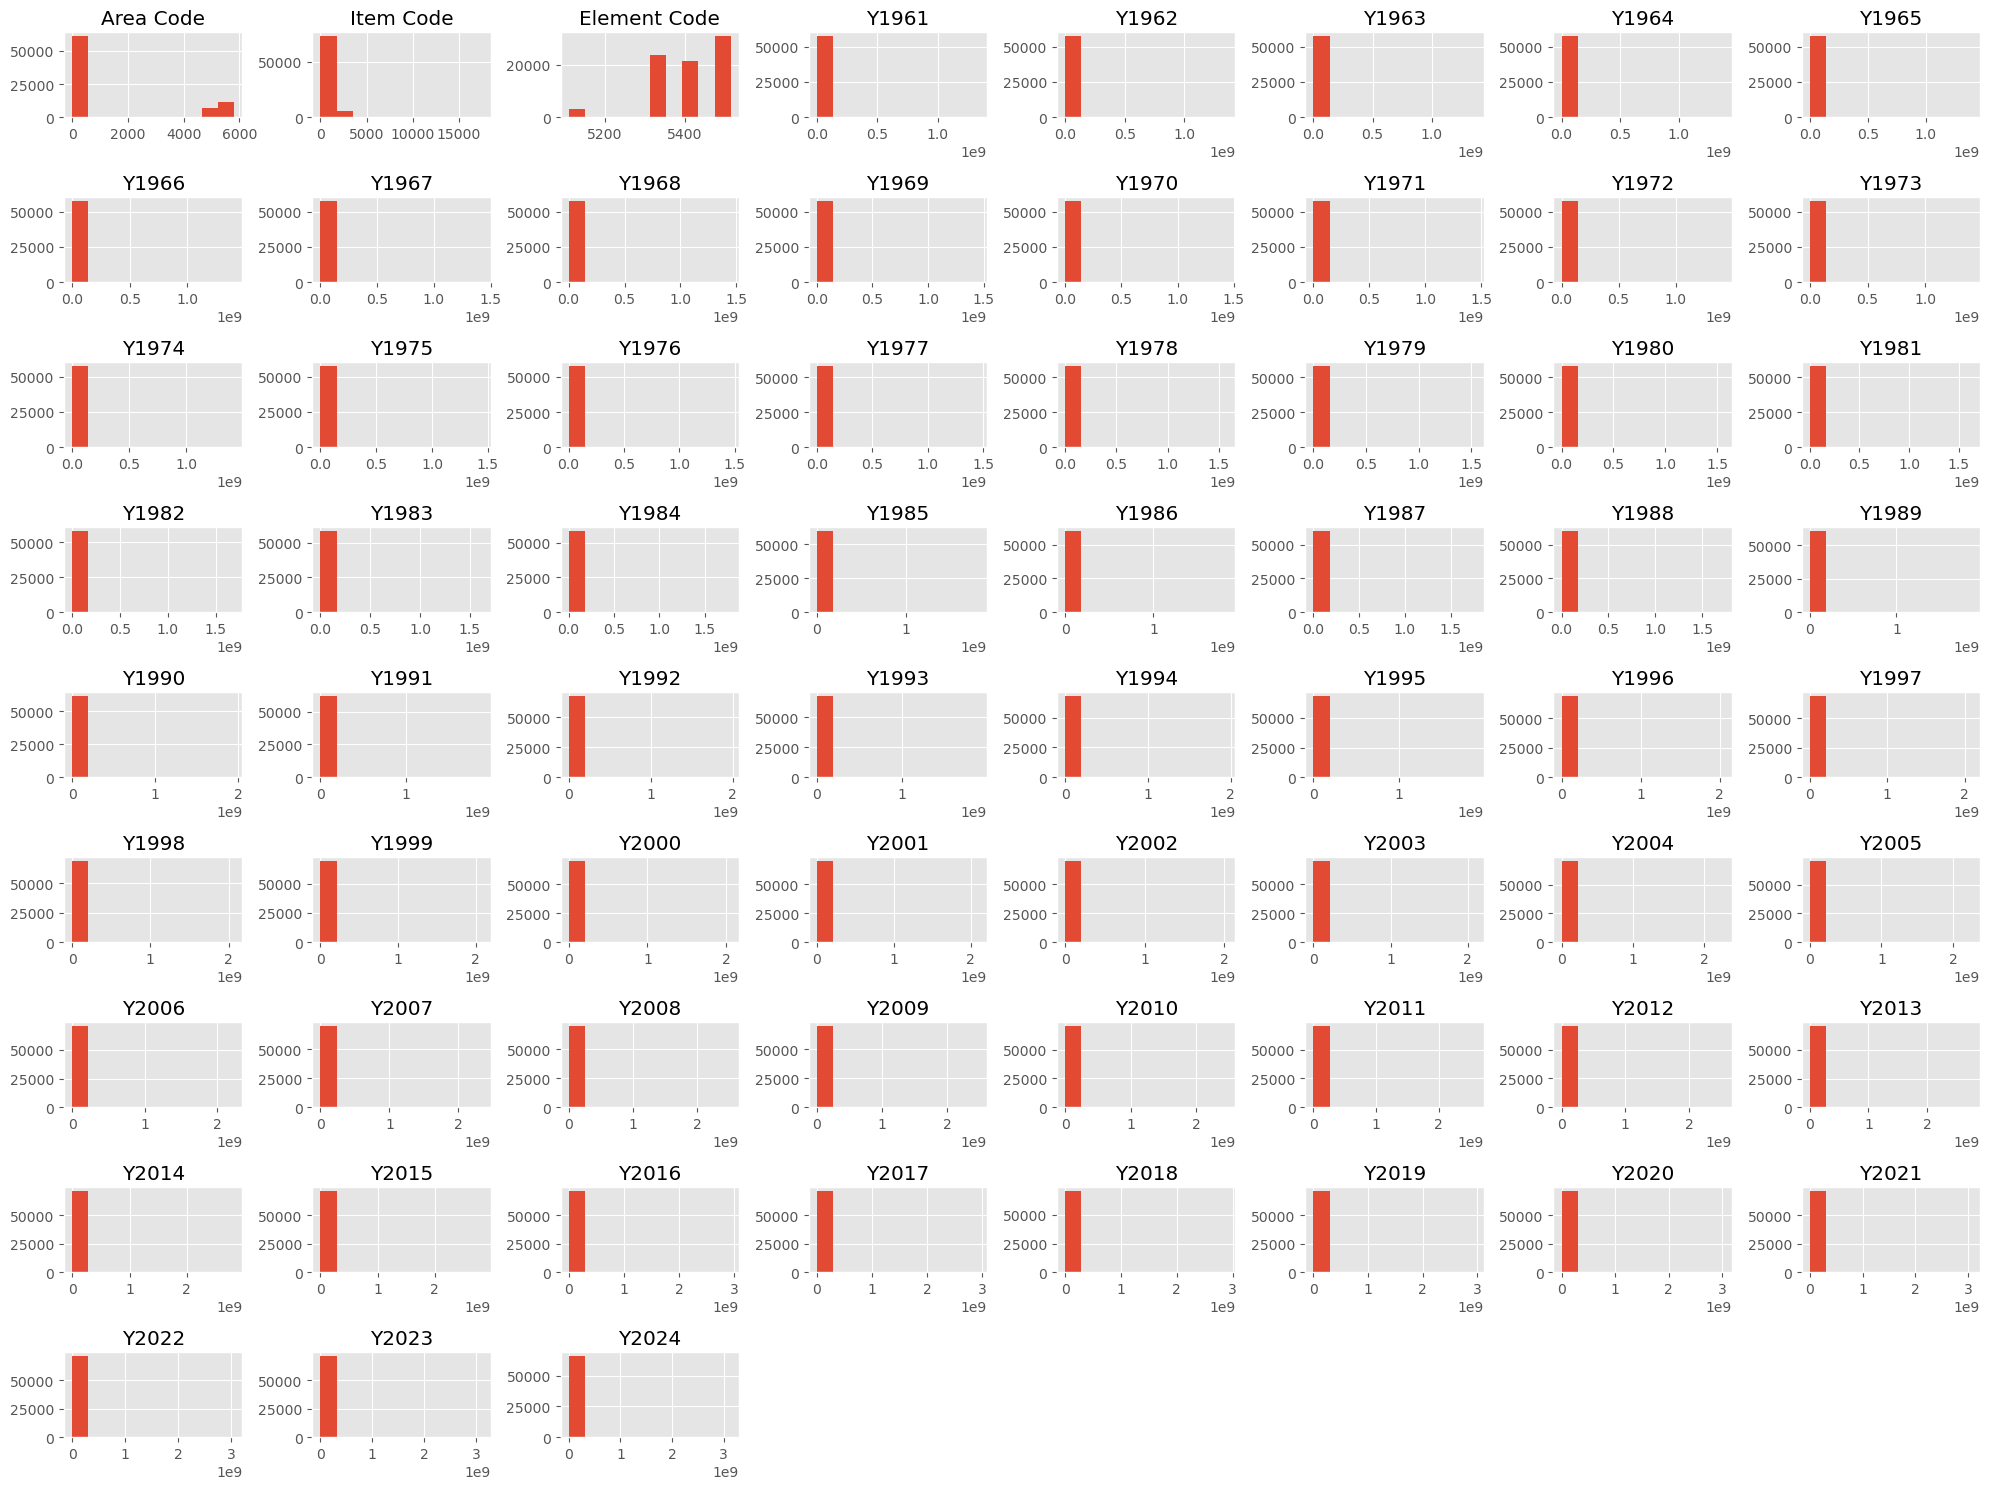

In [15]:
numeric = production.select_dtypes(include=np.number)

numeric.hist(figsize=(20,15))

plt.tight_layout()

plt.show()

In [16]:
import re

def melt_faostat(df):
    """
    Convert FAOSTAT data from wide format to long format.
    Keeps only actual year columns (Y1961, Y1962, ...).
    """

    # Keep only columns exactly like Y1961
    year_columns = [
        col for col in df.columns
        if re.match(r"^Y\d{4}$", col)
    ]

    print(f"Found {len(year_columns)} year columns")
    print("First 5:", year_columns[:5])

    # Everything else is treated as an identifier
    id_columns = [
        col for col in df.columns
        if col not in year_columns
    ]

    long_df = pd.melt(
        df,
        id_vars=id_columns,
        value_vars=year_columns,
        var_name="Year",
        value_name="Value"
    )

    # Remove the leading Y
    long_df["Year"] = (
        long_df["Year"]
        .str.extract(r"(\d{4})")[0]
        .astype(int)
    )

    # Convert values to numeric
    long_df["Value"] = pd.to_numeric(
        long_df["Value"],
        errors="coerce"
    )

    return long_df

In [19]:
production_long = melt_faostat(production)

population_long = melt_faostat(population)

landuse_long = melt_faostat(landuse)

fertilizer_long = melt_faostat(fertilizer)

foodbalance_long = melt_faostat(foodbalance)

foodsecurity_long = melt_faostat(foodsecurity)

print("All datasets transformed successfully.")

Found 64 year columns
First 5: ['Y1961', 'Y1962', 'Y1963', 'Y1964', 'Y1965']
Found 151 year columns
First 5: ['Y1950', 'Y1951', 'Y1952', 'Y1953', 'Y1954']
Found 65 year columns
First 5: ['Y1961', 'Y1962', 'Y1963', 'Y1964', 'Y1965']
Found 63 year columns
First 5: ['Y1961', 'Y1962', 'Y1963', 'Y1964', 'Y1965']
Found 14 year columns
First 5: ['Y2010', 'Y2011', 'Y2012', 'Y2013', 'Y2014']
Found 26 year columns
First 5: ['Y2000', 'Y2001', 'Y2002', 'Y2003', 'Y2004']
All datasets transformed successfully.


In [21]:
print(production_long.head())

print()

print(production_long.shape)

   Area Code Area Code (M49)         Area  Item Code Item Code (CPC)  \
0          2            '004  Afghanistan        221          '01371   
1          2            '004  Afghanistan        221          '01371   
2          2            '004  Afghanistan        221          '01371   
3          2            '004  Afghanistan        711          '01654   
4          2            '004  Afghanistan        711          '01654   

                                                Item  Element Code  \
0                                  Almonds, in shell          5312   
1                                  Almonds, in shell          5412   
2                                  Almonds, in shell          5510   
3  Anise, badian, coriander, cumin, caraway, fenn...          5312   
4  Anise, badian, coriander, cumin, caraway, fenn...          5412   

          Element   Unit Y1961F Y1961N Y1962F Y1962N Y1963F Y1963N Y1964F  \
0  Area harvested     ha      A    NaN      A    NaN      A    NaN   

In [23]:
print("Unique Elements:")
print(production_long["Element"].unique())

Unique Elements:
['Area harvested' 'Yield' 'Production' 'Stocks'
 'Producing Animals/Slaughtered' 'Yield/Carcass Weight' 'Laying'
 'Milk Animals']


In [25]:
print("Unique Items:")
print(production_long["Item"].nunique())

print("\nFirst 30 Items:")
print(production_long["Item"].unique()[:30])

Unique Items:
301

First 30 Items:
['Almonds, in shell'
 'Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw'
 'Apples' 'Apricots' 'Asses' 'Barley' 'Beans, dry'
 'Butter and ghee of sheep milk' 'Butter of cow milk' 'Buttermilk, dry'
 'Camels' 'Cantaloupes and other melons' 'Cattle' 'Cattle fat, unrendered'
 'Cheese from milk of goats, fresh or processed'
 'Cheese from milk of sheep, fresh or processed' 'Chickens'
 'Cotton lint, ginned' 'Cotton seed' 'Cottonseed oil'
 'Edible offal of cattle, fresh, chilled or frozen'
 'Edible offal of goat, fresh, chilled or frozen'
 'Edible offal of sheep, fresh, chilled or frozen'
 'Edible offals of camels and other camelids, fresh, chilled or frozen'
 'Fat of camels' 'Figs' 'Game meat, fresh, chilled or frozen'
 'Goat fat, unrendered' 'Goats' 'Grapes']


In [27]:
production_long[["Area", "Item", "Element", "Unit"]].drop_duplicates().head(20)

,Area,Item,Element,Unit
0,Afghanistan,"Almonds, in shell",Area harvested,ha
1,Afghanistan,"Almonds, in shell",Yield,kg/ha
2,Afghanistan,"Almonds, in shell",Production,t
3,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",Area harvested,ha
4,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",Yield,kg/ha
5,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",Production,t
6,Afghanistan,Apples,Area harvested,ha
7,Afghanistan,Apples,Yield,kg/ha
8,Afghanistan,Apples,Production,t
9,Afghanistan,Apricots,Area harvested,ha


In [29]:
print("Columns in Production Dataset:")
print(production_long.columns.tolist())

Columns in Production Dataset:
['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item Code (CPC)', 'Item', 'Element Code', 'Element', 'Unit', 'Y1961F', 'Y1961N', 'Y1962F', 'Y1962N', 'Y1963F', 'Y1963N', 'Y1964F', 'Y1964N', 'Y1965F', 'Y1965N', 'Y1966F', 'Y1966N', 'Y1967F', 'Y1967N', 'Y1968F', 'Y1968N', 'Y1969F', 'Y1969N', 'Y1970F', 'Y1970N', 'Y1971F', 'Y1971N', 'Y1972F', 'Y1972N', 'Y1973F', 'Y1973N', 'Y1974F', 'Y1974N', 'Y1975F', 'Y1975N', 'Y1976F', 'Y1976N', 'Y1977F', 'Y1977N', 'Y1978F', 'Y1978N', 'Y1979F', 'Y1979N', 'Y1980F', 'Y1980N', 'Y1981F', 'Y1981N', 'Y1982F', 'Y1982N', 'Y1983F', 'Y1983N', 'Y1984F', 'Y1984N', 'Y1985F', 'Y1985N', 'Y1986F', 'Y1986N', 'Y1987F', 'Y1987N', 'Y1988F', 'Y1988N', 'Y1989F', 'Y1989N', 'Y1990F', 'Y1990N', 'Y1991F', 'Y1991N', 'Y1992F', 'Y1992N', 'Y1993F', 'Y1993N', 'Y1994F', 'Y1994N', 'Y1995F', 'Y1995N', 'Y1996F', 'Y1996N', 'Y1997F', 'Y1997N', 'Y1998F', 'Y1998N', 'Y1999F', 'Y1999N', 'Y2000F', 'Y2000N', 'Y2001F', 'Y2001N', 'Y2002F', 'Y2002N', 'Y2003F', 'Y2

In [31]:
print("Unique Elements:")
print(production_long["Element"].unique())

Unique Elements:
['Area harvested' 'Yield' 'Production' 'Stocks'
 'Producing Animals/Slaughtered' 'Yield/Carcass Weight' 'Laying'
 'Milk Animals']


In [33]:
print("Number of unique Items:", production_long["Item"].nunique())

print("\nFirst 50 Items:")
print(sorted(production_long["Item"].unique())[:50])

Number of unique Items: 301

First 50 Items:
['Abaca, manila hemp, raw', 'Agave fibres, raw, n.e.c.', 'Almonds, in shell', 'Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw', 'Apples', 'Apricots', 'Areca nuts', 'Artichokes', 'Asparagus', 'Asses', 'Avocados', 'Balata, gutta-percha, guayule, chicle and similar natural gums in primary forms or in plates, sheets or strip', 'Bambara beans, dry', 'Bananas', 'Barley', 'Beans, dry', 'Beef and Buffalo Meat, primary', 'Beer of barley, malted', 'Bees', 'Beeswax', 'Blueberries', 'Brazil nuts, in shell', 'Broad beans and horse beans, dry', 'Broad beans and horse beans, green', 'Buckwheat', 'Buffalo', 'Buffalo fat, unrendered', 'Butter and Ghee', 'Butter and ghee of sheep milk', 'Butter of buffalo milk', 'Butter of cow milk', 'Buttermilk, dry', 'Cabbages', 'Camels', 'Canary seed', 'Cantaloupes and other melons', 'Carrots and turnips', 'Cashew nuts, in shell', 'Cashewapple', 'Cassava leaves', 'Cassava, fresh', 'Castor oil see

In [35]:
print("Minimum Year:", production_long["Year"].min())
print("Maximum Year:", production_long["Year"].max())

Minimum Year: 1961
Maximum Year: 2024


In [37]:
production_long.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961F,Y1961N,Y1962F,Y1962N,Y1963F,Y1963N,Y1964F,Y1964N,Y1965F,Y1965N,Y1966F,Y1966N,Y1967F,Y1967N,Y1968F,Y1968N,Y1969F,Y1969N,Y1970F,Y1970N,Y1971F,Y1971N,Y1972F,Y1972N,Y1973F,Y1973N,Y1974F,Y1974N,Y1975F,Y1975N,Y1976F,Y1976N,Y1977F,Y1977N,Y1978F,Y1978N,Y1979F,Y1979N,Y1980F,Y1980N,Y1981F,Y1981N,Y1982F,Y1982N,Y1983F,Y1983N,Y1984F,Y1984N,Y1985F,Y1985N,Y1986F,Y1986N,Y1987F,Y1987N,Y1988F,Y1988N,Y1989F,Y1989N,Y1990F,Y1990N,Y1991F,Y1991N,Y1992F,Y1992N,Y1993F,Y1993N,Y1994F,Y1994N,Y1995F,Y1995N,Y1996F,Y1996N,Y1997F,Y1997N,Y1998F,Y1998N,Y1999F,Y1999N,Y2000F,Y2000N,Y2001F,Y2001N,Y2002F,Y2002N,Y2003F,Y2003N,Y2004F,Y2004N,Y2005F,Y2005N,Y2006F,Y2006N,Y2007F,Y2007N,Y2008F,Y2008N,Y2009F,Y2009N,Y2010F,Y2010N,Y2011F,Y2011N,Y2012F,Y2012N,Y2013F,Y2013N,Y2014F,Y2014N,Y2015F,Y2015N,Y2016F,Y2016N,Y2017F,Y2017N,Y2018F,Y2018N,Y2019F,Y2019N,Y2020F,Y2020N,Y2021F,Y2021N,Y2022F,Y2022N,Y2023F,Y2023N,Y2024F,Y2024N,Year,Value
0,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5312,Area harvested,ha,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,E,NaN,E,NaN,A,NaN,A,NaN,X,Unofficial figure,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,1961,0.0
1,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5412,Yield,kg/ha,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,X,NaN,E,NaN,A,NaN,A,NaN,A,NaN,E,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,E,NaN,1961,NaN
2,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5510,Production,t,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,E,NaN,E,NaN,E,NaN,I,NaN,X,Unofficial figure,X,Unofficial figure,X,Unofficial figure,A,NaN,A,NaN,A,NaN,X,Unofficial figure,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,1961,0.0
3,2,'004,Afghanistan,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5312,Area harvested,ha,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,I,NaN,E,NaN,I,NaN,I,NaN,E,NaN,E,NaN,E,NaN,E,NaN,I,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,I,NaN,E,NaN,E,NaN,I,NaN,E,NaN,I,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,I,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,1961,NaN
4,2,'004,Afghanistan,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5412,Yield,kg/ha,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,1961,NaN


In [39]:
production_long.isnull().sum()

Area Code                0
Area Code (M49)          0
Area                     0
Item Code                0
Item Code (CPC)          0
                    ...   
Y2023N             4969792
Y2024F              800832
Y2024N             5019520
Year                     0
Value               939581
Length: 139, dtype: int64

In [40]:
print("Duplicate rows:", production_long.duplicated().sum())

Duplicate rows: 0


In [43]:
print(production_long.shape)

(5054336, 139)


In [45]:
production_filtered = production_long[
    production_long["Element"] == "Production"
].copy()

print("Shape:", production_filtered.shape)

production_filtered.head()

Shape: (1969408, 139)


,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961F,Y1961N,Y1962F,Y1962N,Y1963F,Y1963N,Y1964F,Y1964N,Y1965F,Y1965N,Y1966F,Y1966N,Y1967F,Y1967N,Y1968F,Y1968N,Y1969F,Y1969N,Y1970F,Y1970N,Y1971F,Y1971N,Y1972F,Y1972N,Y1973F,Y1973N,Y1974F,Y1974N,Y1975F,Y1975N,Y1976F,Y1976N,Y1977F,Y1977N,Y1978F,Y1978N,Y1979F,Y1979N,Y1980F,Y1980N,Y1981F,Y1981N,Y1982F,Y1982N,Y1983F,Y1983N,Y1984F,Y1984N,Y1985F,Y1985N,Y1986F,Y1986N,Y1987F,Y1987N,Y1988F,Y1988N,Y1989F,Y1989N,Y1990F,Y1990N,Y1991F,Y1991N,Y1992F,Y1992N,Y1993F,Y1993N,Y1994F,Y1994N,Y1995F,Y1995N,Y1996F,Y1996N,Y1997F,Y1997N,Y1998F,Y1998N,Y1999F,Y1999N,Y2000F,Y2000N,Y2001F,Y2001N,Y2002F,Y2002N,Y2003F,Y2003N,Y2004F,Y2004N,Y2005F,Y2005N,Y2006F,Y2006N,Y2007F,Y2007N,Y2008F,Y2008N,Y2009F,Y2009N,Y2010F,Y2010N,Y2011F,Y2011N,Y2012F,Y2012N,Y2013F,Y2013N,Y2014F,Y2014N,Y2015F,Y2015N,Y2016F,Y2016N,Y2017F,Y2017N,Y2018F,Y2018N,Y2019F,Y2019N,Y2020F,Y2020N,Y2021F,Y2021N,Y2022F,Y2022N,Y2023F,Y2023N,Y2024F,Y2024N,Year,Value
2,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5510,Production,t,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,E,NaN,E,NaN,E,NaN,I,NaN,X,Unofficial figure,X,Unofficial figure,X,Unofficial figure,A,NaN,A,NaN,A,NaN,X,Unofficial figure,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,1961,0.0
5,2,'004,Afghanistan,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5510,Production,t,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,M,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,I,NaN,E,NaN,I,NaN,I,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,I,NaN,E,NaN,E,NaN,I,NaN,E,NaN,I,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,I,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,1961,NaN
8,2,'004,Afghanistan,515,'01341,Apples,5510,Production,t,X,Unofficial figure,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,I,NaN,E,NaN,E,NaN,E,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,E,NaN,E,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,1961,15100.0
11,2,'004,Afghanistan,526,'01343,Apricots,5510,Production,t,X,Unofficial figure,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,I,NaN,E,NaN,E,NaN,I,NaN,E,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,E,NaN,I,NaN,I,NaN,I,NaN,I,NaN,E,NaN,E,NaN,I,NaN,E,NaN,A,NaN,I,NaN,A,NaN,A,NaN,E,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,1961,32000.0
15,2,'004,Afghanistan,44,'0115,Barley,5510,Production,t,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,E,NaN,X,Unofficial figure,X,Unofficial figure,X,Unofficial figure,X,Unofficial figure,A,NaN,E,NaN,X,Unofficial figure,X,Unofficial figure,X,Unofficial figure,X,Unofficial figure,X,Unofficial figure,X,Unofficial figure,X,Unofficial figure,X,Unofficial figure,X,Unofficial figure,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,X,Unofficial figure,1961,378000.0


In [47]:
print(production_filtered["Element"].unique())

['Production']


print("Number of Countries:", production_filtered["Area"].nunique())

print("Number of Items:", production_filtered["Item"].nunique())

print("Year Range:",
      production_filtered["Year"].min(),
      "-",
      production_filtered["Year"].max())

## Cleaning the Production Dataset

In [51]:
production_clean = production_filtered[
    [
        "Area",
        "Item",
        "Year",
        "Value"
    ]
].copy()

production_clean.rename(
    columns={"Value":"Production"},
    inplace=True
)

production_clean.drop_duplicates(inplace=True)

production_clean.dropna(subset=["Production"], inplace=True)

production_clean.head()

,Area,Item,Year,Production
2,Afghanistan,"Almonds, in shell",1961,0.0
8,Afghanistan,Apples,1961,15100.0
11,Afghanistan,Apricots,1961,32000.0
15,Afghanistan,Barley,1961,378000.0
19,Afghanistan,Butter and ghee of sheep milk,1961,4104.0


## Preparing the Population Dataset

In [54]:
print(population_long["Element"].unique())
print(population_long["Item"].unique())
print(population_long["Unit"].unique())

['Total Population - Both sexes' 'Total Population - Male'
 'Total Population - Female' 'Rural population' 'Urban population']
['Population - Est. & Proj.']
['1000 No']


In [56]:
population_filtered = population_long[
    population_long["Element"] == "Total Population - Both sexes"
].copy()

population_filtered.head()

,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Unit,Y1950F,Y1950N,Y1951F,Y1951N,Y1952F,Y1952N,Y1953F,Y1953N,Y1954F,Y1954N,Y1955F,Y1955N,Y1956F,Y1956N,Y1957F,Y1957N,Y1958F,Y1958N,Y1959F,Y1959N,Y1960F,Y1960N,Y1961F,Y1961N,Y1962F,Y1962N,Y1963F,Y1963N,Y1964F,Y1964N,Y1965F,Y1965N,Y1966F,Y1966N,Y1967F,Y1967N,Y1968F,Y1968N,Y1969F,Y1969N,Y1970F,Y1970N,Y1971F,Y1971N,Y1972F,Y1972N,Y1973F,Y1973N,Y1974F,Y1974N,Y1975F,Y1975N,Y1976F,Y1976N,Y1977F,Y1977N,Y1978F,Y1978N,Y1979F,Y1979N,Y1980F,Y1980N,Y1981F,Y1981N,Y1982F,Y1982N,Y1983F,Y1983N,Y1984F,Y1984N,Y1985F,Y1985N,Y1986F,Y1986N,Y1987F,Y1987N,Y1988F,Y1988N,Y1989F,Y1989N,Y1990F,Y1990N,Y1991F,Y1991N,Y1992F,Y1992N,Y1993F,Y1993N,Y1994F,Y1994N,Y1995F,Y1995N,Y1996F,Y1996N,Y1997F,Y1997N,Y1998F,Y1998N,Y1999F,Y1999N,Y2000F,Y2000N,Y2001F,Y2001N,Y2002F,Y2002N,Y2003F,Y2003N,Y2004F,Y2004N,Y2005F,Y2005N,Y2006F,Y2006N,Y2007F,Y2007N,Y2008F,Y2008N,Y2009F,Y2009N,Y2010F,Y2010N,Y2011F,Y2011N,Y2012F,Y2012N,Y2013F,Y2013N,Y2014F,Y2014N,Y2015F,Y2015N,Y2016F,Y2016N,Y2017F,Y2017N,Y2018F,Y2018N,Y2019F,Y2019N,Y2020F,Y2020N,Y2021F,Y2021N,Y2022F,Y2022N,Y2023F,Y2023N,Y2024F,Y2024N,Y2025F,Y2025N,Y2026F,Y2026N,Y2027F,Y2027N,Y2028F,Y2028N,Y2029F,Y2029N,Y2030F,Y2030N,Y2031F,Y2031N,Y2032F,Y2032N,Y2033F,Y2033N,Y2034F,Y2034N,Y2035F,Y2035N,Y2036F,Y2036N,Y2037F,Y2037N,Y2038F,Y2038N,Y2039F,Y2039N,Y2040F,Y2040N,Y2041F,Y2041N,Y2042F,Y2042N,Y2043F,Y2043N,Y2044F,Y2044N,Y2045F,Y2045N,Y2046F,Y2046N,Y2047F,Y2047N,Y2048F,Y2048N,Y2049F,Y2049N,Y2050F,Y2050N,Y2051F,Y2051N,Y2052F,Y2052N,Y2053F,Y2053N,Y2054F,Y2054N,Y2055F,Y2055N,Y2056F,Y2056N,Y2057F,Y2057N,Y2058F,Y2058N,Y2059F,Y2059N,Y2060F,Y2060N,Y2061F,Y2061N,Y2062F,Y2062N,Y2063F,Y2063N,Y2064F,Y2064N,Y2065F,Y2065N,Y2066F,Y2066N,Y2067F,Y2067N,Y2068F,Y2068N,Y2069F,Y2069N,Y2070F,Y2070N,Y2071F,Y2071N,Y2072F,Y2072N,Y2073F,Y2073N,Y2074F,Y2074N,Y2075F,Y2075N,Y2076F,Y2076N,Y2077F,Y2077N,Y2078F,Y2078N,Y2079F,Y2079N,Y2080F,Y2080N,Y2081F,Y2081N,Y2082F,Y2082N,Y2083F,Y2083N,Y2084F,Y2084N,Y2085F,Y2085N,Y2086F,Y2086N,Y2087F,Y2087N,Y2088F,Y2088N,Y2089F,Y2089N,Y2090F,Y2090N,Y2091F,Y2091N,Y2092F,Y2092N,Y2093F,Y2093N,Y2094F,Y2094N,Y2095F,Y2095N,Y2096F,Y2096N,Y2097F,Y2097N,Y2098F,Y2098N,Y2099F,Y2099N,Y2100F,Y2100N,Year,Value
0,2,'004,Afghanistan,3010,Population - Est. & Proj.,511,Total Population - Both sexes,1000 No,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,1950,7776.176
5,3,'008,Albania,3010,Population - Est. & Proj.,511,Total Population - Both sexes,1000 No,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,NaN,X,

In [57]:
population_filtered = population_long[
    population_long["Element"] == "Total Population - Both sexes"
].copy()

In [60]:
population_clean = population_filtered[
    ["Area", "Year", "Value"]
].copy()

population_clean.rename(
    columns={"Value": "Population"},
    inplace=True
)

population_clean.drop_duplicates(inplace=True)
population_clean.dropna(subset=["Population"], inplace=True)

population_clean.head()

,Area,Year,Population
0,Afghanistan,1950,7776.176
5,Albania,1950,1247.851
10,Algeria,1950,9018.426
15,American Samoa,1950,19.043
20,Andorra,1950,5.996


In [62]:
print(population_clean.shape)

population_clean.isnull().sum()

population_clean.head()

(38973, 3)


,Area,Year,Population
0,Afghanistan,1950,7776.176
5,Albania,1950,1247.851
10,Algeria,1950,9018.426
15,American Samoa,1950,19.043
20,Andorra,1950,5.996


In [64]:
population_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38973 entries, 0 to 209130
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        38973 non-null  object 
 1   Year        38973 non-null  int32  
 2   Population  38973 non-null  float64
dtypes: float64(1), int32(1), object(1)
memory usage: 1.0+ MB


In [66]:
production_filtered.isnull().sum()

Area Code                0
Area Code (M49)          0
Area                     0
Item Code                0
Item Code (CPC)          0
                    ...   
Y2023N             1900160
Y2024F              509824
Y2024N             1948480
Year                     0
Value               370756
Length: 139, dtype: int64

In [68]:
production_clean.to_csv(
    "production_clean.csv",
    index=False
)

In [70]:
population_clean.to_csv(
    "population_clean.csv",
    index=False
)

In [72]:
print("Unique Elements:")
print(landuse_long["Element"].unique())

print("\nUnique Items:")
print(landuse_long["Item"].unique())

print("\nUnique Units:")
print(landuse_long["Unit"].unique())

Unique Elements:
['Area' 'Share in Land area'
 'Value of agricultural production (Int. $) per Area'
 'Share in Agricultural land' 'Area per capita'
 'Carbon stock in living biomass' 'Share in Forest land'
 'Share in Cropland']

Unique Items:
['Country area' 'Land area' 'Agriculture' 'Agricultural land' 'Cropland'
 'Arable land' 'Temporary crops' 'Temporary meadows and pastures'
 'Temporary fallow' 'Permanent crops' 'Permanent meadows and pastures'
 'Perm. meadows & pastures - Nat. growing' 'Forest land'
 'Naturally regenerating forest' 'Other land' 'Inland waters'
 'Land area equipped for irrigation' 'Land area actually irrigated'
 'Agriculture area actually irrigated'
 'Agriculture area under organic agric.'
 'Agriculture area certified organic' 'Farm buildings and Farmyards'
 'Primary Forest' 'Coastal waters' 'Cropland area actually irrigated'
 'Cropland area under organic agric.' 'Cropland area certified organic'
 'Cropland area under protective cover'
 'Perm. meadows & pastures - C

In [74]:
print(landuse_long.shape)

landuse_long.info()

landuse_long.head()

(660270, 140)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660270 entries, 0 to 660269
Columns: 140 entries, Area Code to Value
dtypes: float64(66), int32(1), int64(3), object(70)
memory usage: 702.7+ MB


,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Unit,Y1961F,Y1961N,Y1962F,Y1962N,Y1963F,Y1963N,Y1964F,Y1964N,Y1965F,Y1965N,Y1966F,Y1966N,Y1967F,Y1967N,Y1968F,Y1968N,Y1969F,Y1969N,Y1970F,Y1970N,Y1971F,Y1971N,Y1972F,Y1972N,Y1973F,Y1973N,Y1974F,Y1974N,Y1975F,Y1975N,Y1976F,Y1976N,Y1977F,Y1977N,Y1978F,Y1978N,Y1979F,Y1979N,Y1980F,Y1980N,Y1981F,Y1981N,Y1982F,Y1982N,Y1983F,Y1983N,Y1984F,Y1984N,Y1985F,Y1985N,Y1986F,Y1986N,Y1987F,Y1987N,Y1988F,Y1988N,Y1989F,Y1989N,Y1990F,Y1990N,Y1991F,Y1991N,Y1992F,Y1992N,Y1993F,Y1993N,Y1994F,Y1994N,Y1995F,Y1995N,Y1996F,Y1996N,Y1997F,Y1997N,Y1998F,Y1998N,Y1999F,Y1999N,Y2000F,Y2000N,Y2001F,Y2001N,Y2002F,Y2002N,Y2003F,Y2003N,Y2004F,Y2004N,Y2005F,Y2005N,Y2006F,Y2006N,Y2007F,Y2007N,Y2008F,Y2008N,Y2009F,Y2009N,Y2010F,Y2010N,Y2011F,Y2011N,Y2012F,Y2012N,Y2013F,Y2013N,Y2014F,Y2014N,Y2015F,Y2015N,Y2016F,Y2016N,Y2017F,Y2017N,Y2018F,Y2018N,Y2019F,Y2019N,Y2020F,Y2020N,Y2021F,Y2021N,Y2022F,Y2022N,Y2023F,Y2023N,Y2024F,Y2024N,Y2025F,Y2025N,Year,Value
0,2,'004,Afghanistan,6600,Country area,5110,Area,1000 ha,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,A,NaN,NaN,NaN,NaN,NaN,1961,65286.00
1,2,'004,Afghanistan,6601,Land area,5110,Area,1000 ha,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,NaN,NaN,NaN,NaN,1961,65223.00
2,2,'004,Afghanistan,6602,Agriculture,5110,Area,1000 ha,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,NaN,NaN,NaN,NaN,1961,37750.00
3,2,'004,Afghanistan,6610,Agricultural land,5110,Area,1000 ha,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,NaN,NaN,NaN,NaN,1961,37750.00
4,2,'004,Afghanistan,6610,Agricultural land,7209,Share in Land area,%,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,A,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,NaN,NaN,NaN,NaN,1961,57.88


In [76]:
landuse_long.isnull().sum()

Area Code               0
Area Code (M49)         0
Area                    0
Item Code               0
Item                    0
                    ...  
Y2024N             660270
Y2025F             551330
Y2025N             660270
Year                    0
Value              247059
Length: 140, dtype: int64

In [77]:
landuse_filtered = landuse_long[
    landuse_long["Element"] == "Area"
].copy()

landuse_filtered.head()

,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Unit,Y1961F,Y1961N,Y1962F,Y1962N,Y1963F,Y1963N,Y1964F,Y1964N,Y1965F,Y1965N,Y1966F,Y1966N,Y1967F,Y1967N,Y1968F,Y1968N,Y1969F,Y1969N,Y1970F,Y1970N,Y1971F,Y1971N,Y1972F,Y1972N,Y1973F,Y1973N,Y1974F,Y1974N,Y1975F,Y1975N,Y1976F,Y1976N,Y1977F,Y1977N,Y1978F,Y1978N,Y1979F,Y1979N,Y1980F,Y1980N,Y1981F,Y1981N,Y1982F,Y1982N,Y1983F,Y1983N,Y1984F,Y1984N,Y1985F,Y1985N,Y1986F,Y1986N,Y1987F,Y1987N,Y1988F,Y1988N,Y1989F,Y1989N,Y1990F,Y1990N,Y1991F,Y1991N,Y1992F,Y1992N,Y1993F,Y1993N,Y1994F,Y1994N,Y1995F,Y1995N,Y1996F,Y1996N,Y1997F,Y1997N,Y1998F,Y1998N,Y1999F,Y1999N,Y2000F,Y2000N,Y2001F,Y2001N,Y2002F,Y2002N,Y2003F,Y2003N,Y2004F,Y2004N,Y2005F,Y2005N,Y2006F,Y2006N,Y2007F,Y2007N,Y2008F,Y2008N,Y2009F,Y2009N,Y2010F,Y2010N,Y2011F,Y2011N,Y2012F,Y2012N,Y2013F,Y2013N,Y2014F,Y2014N,Y2015F,Y2015N,Y2016F,Y2016N,Y2017F,Y2017N,Y2018F,Y2018N,Y2019F,Y2019N,Y2020F,Y2020N,Y2021F,Y2021N,Y2022F,Y2022N,Y2023F,Y2023N,Y2024F,Y2024N,Y2025F,Y2025N,Year,Value
0,2,'004,Afghanistan,6600,Country area,5110,Area,1000 ha,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,A,NaN,NaN,NaN,NaN,NaN,1961,65286.0
1,2,'004,Afghanistan,6601,Land area,5110,Area,1000 ha,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,NaN,NaN,NaN,NaN,1961,65223.0
2,2,'004,Afghanistan,6602,Agriculture,5110,Area,1000 ha,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,NaN,NaN,NaN,NaN,1961,37750.0
3,2,'004,Afghanistan,6610,Agricultural land,5110,Area,1000 ha,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,NaN,NaN,NaN,NaN,1961,37750.0
6,2,'004,Afghanistan,6620,Cropland,5110,Area,1000 ha,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,A,NaN,NaN,NaN,NaN,NaN,1961,7750.0


In [79]:
print("Shape:", landuse_filtered.shape)

print("\nUnique Items:")
print(landuse_filtered["Item"].unique())

Shape: (402415, 140)

Unique Items:
['Country area' 'Land area' 'Agriculture' 'Agricultural land' 'Cropland'
 'Arable land' 'Temporary crops' 'Temporary meadows and pastures'
 'Temporary fallow' 'Permanent crops' 'Permanent meadows and pastures'
 'Perm. meadows & pastures - Nat. growing' 'Forest land'
 'Naturally regenerating forest' 'Other land' 'Inland waters'
 'Land area equipped for irrigation' 'Land area actually irrigated'
 'Agriculture area actually irrigated'
 'Agriculture area under organic agric.'
 'Agriculture area certified organic' 'Farm buildings and Farmyards'
 'Primary Forest' 'Coastal waters' 'Cropland area actually irrigated'
 'Cropland area under organic agric.' 'Cropland area certified organic'
 'Cropland area under protective cover'
 'Perm. meadows & pastures - Cultivated' 'Planted Forest'
 'Land used for aquaculture' 'EEZ used for capture fisheries'
 'Perm. meadows & pastures area actually irrig.'
 'Forestry area actually irrigated'
 'Perm. meadows & pastures area

In [82]:
landuse_filtered = landuse_filtered[
    landuse_filtered["Item"].isin([
        "Agricultural land",
        "Cropland",
        "Arable land"
    ])
].copy()

landuse_filtered.head()

,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Unit,Y1961F,Y1961N,Y1962F,Y1962N,Y1963F,Y1963N,Y1964F,Y1964N,Y1965F,Y1965N,Y1966F,Y1966N,Y1967F,Y1967N,Y1968F,Y1968N,Y1969F,Y1969N,Y1970F,Y1970N,Y1971F,Y1971N,Y1972F,Y1972N,Y1973F,Y1973N,Y1974F,Y1974N,Y1975F,Y1975N,Y1976F,Y1976N,Y1977F,Y1977N,Y1978F,Y1978N,Y1979F,Y1979N,Y1980F,Y1980N,Y1981F,Y1981N,Y1982F,Y1982N,Y1983F,Y1983N,Y1984F,Y1984N,Y1985F,Y1985N,Y1986F,Y1986N,Y1987F,Y1987N,Y1988F,Y1988N,Y1989F,Y1989N,Y1990F,Y1990N,Y1991F,Y1991N,Y1992F,Y1992N,Y1993F,Y1993N,Y1994F,Y1994N,Y1995F,Y1995N,Y1996F,Y1996N,Y1997F,Y1997N,Y1998F,Y1998N,Y1999F,Y1999N,Y2000F,Y2000N,Y2001F,Y2001N,Y2002F,Y2002N,Y2003F,Y2003N,Y2004F,Y2004N,Y2005F,Y2005N,Y2006F,Y2006N,Y2007F,Y2007N,Y2008F,Y2008N,Y2009F,Y2009N,Y2010F,Y2010N,Y2011F,Y2011N,Y2012F,Y2012N,Y2013F,Y2013N,Y2014F,Y2014N,Y2015F,Y2015N,Y2016F,Y2016N,Y2017F,Y2017N,Y2018F,Y2018N,Y2019F,Y2019N,Y2020F,Y2020N,Y2021F,Y2021N,Y2022F,Y2022N,Y2023F,Y2023N,Y2024F,Y2024N,Y2025F,Y2025N,Year,Value
3,2,'004,Afghanistan,6610,Agricultural land,5110,Area,1000 ha,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,NaN,NaN,NaN,NaN,1961,37750.0
6,2,'004,Afghanistan,6620,Cropland,5110,Area,1000 ha,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,A,NaN,NaN,NaN,NaN,NaN,1961,7750.0
10,2,'004,Afghanistan,6621,Arable land,5110,Area,1000 ha,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,I,NaN,I,NaN,A,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,NaN,NaN,NaN,NaN,1961,7650.0
39,3,'008,Albania,6610,Agricultural land,5110,Area,1000 ha,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,I,NaN,I,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,I,NaN,I,NaN,A,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,NaN,NaN,NaN,NaN,1961,1232.0
42,3,'008,Albania,6620,Cropland,5110,Area,1000 ha,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,I,NaN,I,NaN,A,NaN,I,NaN,I,NaN,A,NaN,I,NaN,I,NaN,I,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,I,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,NaN,NaN,NaN,NaN,1961,479.0


In [84]:
print("Shape:", landuse_filtered.shape)

print("\nUnique Items:")
print(landuse_filtered["Item"].unique())

Shape: (52650, 140)

Unique Items:
['Agricultural land' 'Cropland' 'Arable land']


In [86]:
landuse_clean = landuse_filtered.pivot_table(
    index=["Area", "Year"],
    columns="Item",
    values="Value",
    aggfunc="first"
).reset_index()

landuse_clean.head()

Item,Area,Year,Agricultural land,Arable land,Cropland
0,Afghanistan,1961,37750.0,7650.0,7750.0
1,Afghanistan,1962,37800.0,7700.0,7800.0
2,Afghanistan,1963,37850.0,7750.0,7850.0
3,Afghanistan,1964,37905.0,7800.0,7905.0
4,Afghanistan,1965,37910.0,7800.0,7910.0


In [88]:
landuse_clean.rename(
    columns={
        "Agricultural land": "Agricultural_Land",
        "Cropland": "Cropland",
        "Arable land": "Arable_Land"
    },
    inplace=True
)

landuse_clean.head()

Item,Area,Year,Agricultural_Land,Arable_Land,Cropland
0,Afghanistan,1961,37750.0,7650.0,7750.0
1,Afghanistan,1962,37800.0,7700.0,7800.0
2,Afghanistan,1963,37850.0,7750.0,7850.0
3,Afghanistan,1964,37905.0,7800.0,7905.0
4,Afghanistan,1965,37910.0,7800.0,7910.0


In [90]:
print(landuse_clean.shape)

landuse_clean.info()

landuse_clean.head()

(15804, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15804 entries, 0 to 15803
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               15804 non-null  object 
 1   Year               15804 non-null  int32  
 2   Agricultural_Land  15804 non-null  float64
 3   Arable_Land        15418 non-null  float64
 4   Cropland           15607 non-null  float64
dtypes: float64(3), int32(1), object(1)
memory usage: 555.7+ KB


Item,Area,Year,Agricultural_Land,Arable_Land,Cropland
0,Afghanistan,1961,37750.0,7650.0,7750.0
1,Afghanistan,1962,37800.0,7700.0,7800.0
2,Afghanistan,1963,37850.0,7750.0,7850.0
3,Afghanistan,1964,37905.0,7800.0,7905.0
4,Afghanistan,1965,37910.0,7800.0,7910.0


In [92]:
landuse_clean.isnull().sum()

Item
Area                   0
Year                   0
Agricultural_Land      0
Arable_Land          386
Cropland             197
dtype: int64

In [94]:
landuse_clean.duplicated().sum()

0

In [96]:
landuse_clean.to_csv(
    "landuse_clean.csv",
    index=False
)

print("Land Use dataset saved successfully!")

Land Use dataset saved successfully!


# Preparing the Fertilizer Dataset

In [99]:
print("Unique Elements:")
print(fertilizer_long["Element"].unique())

print("\nUnique Items:")
print(fertilizer_long["Item"].unique())

print("\nUnique Units:")
print(fertilizer_long["Unit"].unique())

Unique Elements:
['Production' 'Import quantity' 'Export quantity' 'Agricultural Use'
 'Use per area of cropland' 'Use per capita'
 'Use per value of agricultural production']

Unique Items:
['Nutrient nitrogen N (total)' 'Nutrient phosphate P2O5 (total)'
 'Nutrient potash K2O (total)']

Unique Units:
['t' 'kg/ha' 'kg/cap' 'g/Int$']


In [101]:
fertilizer_filtered = fertilizer_long[
    fertilizer_long["Element"] == "Agricultural Use"
].copy()

fertilizer_filtered.head()

,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Unit,Y1961F,Y1961N,Y1962F,Y1962N,Y1963F,Y1963N,Y1964F,Y1964N,Y1965F,Y1965N,Y1966F,Y1966N,Y1967F,Y1967N,Y1968F,Y1968N,Y1969F,Y1969N,Y1970F,Y1970N,Y1971F,Y1971N,Y1972F,Y1972N,Y1973F,Y1973N,Y1974F,Y1974N,Y1975F,Y1975N,Y1976F,Y1976N,Y1977F,Y1977N,Y1978F,Y1978N,Y1979F,Y1979N,Y1980F,Y1980N,Y1981F,Y1981N,Y1982F,Y1982N,Y1983F,Y1983N,Y1984F,Y1984N,Y1985F,Y1985N,Y1986F,Y1986N,Y1987F,Y1987N,Y1988F,Y1988N,Y1989F,Y1989N,Y1990F,Y1990N,Y1991F,Y1991N,Y1992F,Y1992N,Y1993F,Y1993N,Y1994F,Y1994N,Y1995F,Y1995N,Y1996F,Y1996N,Y1997F,Y1997N,Y1998F,Y1998N,Y1999F,Y1999N,Y2000F,Y2000N,Y2001F,Y2001N,Y2002F,Y2002N,Y2003F,Y2003N,Y2004F,Y2004N,Y2005F,Y2005N,Y2006F,Y2006N,Y2007F,Y2007N,Y2008F,Y2008N,Y2009F,Y2009N,Y2010F,Y2010N,Y2011F,Y2011N,Y2012F,Y2012N,Y2013F,Y2013N,Y2014F,Y2014N,Y2015F,Y2015N,Y2016F,Y2016N,Y2017F,Y2017N,Y2018F,Y2018N,Y2019F,Y2019N,Y2020F,Y2020N,Y2021F,Y2021N,Y2022F,Y2022N,Y2023F,Y2023N,Year,Value
3,2,'004,Afghanistan,3102,Nutrient nitrogen N (total),5157,Agricultural Use,t,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,X,Data sourced from another international organi...,X,Data sourced from another international organi...,X,Data sourced from another international organi...,X,Data sourced from another international organi...,X,Data sourced from another international organi...,X,Data sourced from another international organi...,E,NaN,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,X,Data sourced from another international organi...,A,Official data from questionnaire,A,Official data from questionnaire,X,Data sourced from another international organi...,X,Data sourced from another international organi...,X,Data sourced from another international organi...,X,Data sourced from another international organi...,NaN,NaN,NaN,NaN,X,Data sourced from another international organi...,X,Data sourced from another international organi...,X,Data sourced from another international organi...,X,Data sourced from another international organi...,X,Data sourced from another international organi...,X,Data sourced from another international organi...,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,1961,1000.0
10,2,'004,Afghanistan,3103,Nutrient phosphate P2O5 (total),5157,Agricultural Use,t,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,X,Data sourced from another international organi...,X,Data sourced from another international organi...,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,A,Official data from questionnaire,X,Data sourced from another international organi...,X,Data sourced from another international organi...,X,Data sourced from another international organi...,X,Data sourced from another international organi...,X,Data sourced from another international organi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,X,Data sourced from another international organi...,NaN,NaN,NaN,NaN,NaN,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,I,NaN,1961,10

In [102]:
print("Shape:", fertilizer_filtered.shape)

print("\nUnique Items:")
print(fertilizer_filtered["Item"].unique())

Shape: (45927, 136)

Unique Items:
['Nutrient nitrogen N (total)' 'Nutrient phosphate P2O5 (total)'
 'Nutrient potash K2O (total)']


In [105]:
fertilizer_clean = fertilizer_filtered.pivot_table(
    index=["Area", "Year"],
    columns="Item",
    values="Value",
    aggfunc="first"
).reset_index()

fertilizer_clean.head()

Item,Area,Year,Nutrient nitrogen N (total),Nutrient phosphate P2O5 (total),Nutrient potash K2O (total)
0,Afghanistan,1961,1000.0,100.0,NaN
1,Afghanistan,1962,1000.0,100.0,NaN
2,Afghanistan,1963,1000.0,100.0,NaN
3,Afghanistan,1964,1000.0,100.0,NaN
4,Afghanistan,1965,1000.0,100.0,NaN


In [107]:
fertilizer_clean.rename(
    columns={
        "Nutrient nitrogen N (total)": "Nitrogen",
        "Nutrient phosphate P2O5 (total)": "Phosphate",
        "Nutrient potash K2O (total)": "Potash"
    },
    inplace=True
)

fertilizer_clean.head()

Item,Area,Year,Nitrogen,Phosphate,Potash
0,Afghanistan,1961,1000.0,100.0,NaN
1,Afghanistan,1962,1000.0,100.0,NaN
2,Afghanistan,1963,1000.0,100.0,NaN
3,Afghanistan,1964,1000.0,100.0,NaN
4,Afghanistan,1965,1000.0,100.0,NaN


In [109]:
print(fertilizer_clean.shape)

fertilizer_clean.info()

fertilizer_clean.head()

fertilizer_clean.isnull().sum()

print("Duplicate rows:", fertilizer_clean.duplicated().sum())

(12628, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12628 entries, 0 to 12627
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area       12628 non-null  object 
 1   Year       12628 non-null  int32  
 2   Nitrogen   12590 non-null  float64
 3   Phosphate  12302 non-null  float64
 4   Potash     12023 non-null  float64
dtypes: float64(3), int32(1), object(1)
memory usage: 444.1+ KB
Duplicate rows: 0


In [111]:
fertilizer_clean.to_csv(
    "fertilizer_clean.csv",
    index=False
)

print("Fertilizer dataset saved successfully!")

Fertilizer dataset saved successfully!


# Preparing the Food Balance Dataset

In [114]:
print("Unique Elements:")
print(foodbalance_long["Element"].unique())

print("\nUnique Items:")
print(foodbalance_long["Item"].unique())

print("\nUnique Units:")
print(foodbalance_long["Unit"].unique())

Unique Elements:
['Total Population - Both sexes' 'Food supply (kcal/capita/day)'
 'Food supply (kcal)' 'Protein supply quantity (g/capita/day)'
 'Protein supply quantity (t)' 'Fat supply quantity (g/capita/day)'
 'Fat supply quantity (t)' 'Production' 'Import quantity'
 'Stock Variation' 'Export quantity' 'Domestic supply quantity' 'Feed'
 'Seed' 'Losses' 'Processing' 'Other uses (non-food)' 'Residuals' 'Food'
 'Food supply quantity (kg/capita/yr)' 'Tourist consumption']

Unique Items:
['Population' 'Grand Total' 'Vegetal Products' 'Animal Products'
 'Cereals - Excluding Beer' 'Wheat and products' 'Rice and products'
 'Barley and products' 'Maize and products' 'Rye and products' 'Oats'
 'Millet and products' 'Sorghum and products' 'Cereals, other'
 'Starchy Roots' 'Cassava and products' 'Potatoes and products'
 'Sweet potatoes' 'Yams' 'Roots, Other' 'Sugar Crops' 'Sugar cane'
 'Sugar beet' 'Sugar & Sweeteners' 'Sugar non-centrifugal'
 'Sugar (Raw Equivalent)' 'Sweeteners, Other' 'Hone

In [116]:
foodbalance_filtered = foodbalance_long[
    foodbalance_long["Element"] == "Food supply (kcal/capita/day)"
].copy()

foodbalance_filtered.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (FBS),Item,Element Code,Element,Unit,Y2010F,Y2010N,Y2011F,Y2011N,Y2012F,Y2012N,Y2013F,Y2013N,Y2014F,Y2014N,Y2015F,Y2015N,Y2016F,Y2016N,Y2017F,Y2017N,Y2018F,Y2018N,Y2019F,Y2019N,Y2020F,Y2020N,Y2021F,Y2021N,Y2022F,Y2022N,Y2023F,Y2023N,Year,Value
1,2,'004,Afghanistan,2901,'S2901,Grand Total,664,Food supply (kcal/capita/day),kcal/cap/d,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,2010,2200.21
7,2,'004,Afghanistan,2903,'S2903,Vegetal Products,664,Food supply (kcal/capita/day),kcal/cap/d,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,2010,2000.82
13,2,'004,Afghanistan,2941,'S2941,Animal Products,664,Food supply (kcal/capita/day),kcal/cap/d,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,2010,199.39
32,2,'004,Afghanistan,2905,'S2905,Cereals - Excluding Beer,664,Food supply (kcal/capita/day),kcal/cap/d,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,2010,1648.94
50,2,'004,Afghanistan,2511,'S2511,Wheat and products,664,Food supply (kcal/capita/day),kcal/cap/d,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,2010,1464.44


In [117]:
print("Shape:", foodbalance_filtered.shape)

print("\nUnique Items:")
print(foodbalance_filtered["Item"].unique())

Shape: (327418, 39)

Unique Items:
['Grand Total' 'Vegetal Products' 'Animal Products'
 'Cereals - Excluding Beer' 'Wheat and products' 'Rice and products'
 'Barley and products' 'Maize and products' 'Rye and products' 'Oats'
 'Millet and products' 'Sorghum and products' 'Cereals, other'
 'Starchy Roots' 'Cassava and products' 'Potatoes and products'
 'Sweet potatoes' 'Roots, Other' 'Sugar & Sweeteners'
 'Sugar (Raw Equivalent)' 'Sweeteners, Other' 'Honey' 'Pulses' 'Beans'
 'Peas' 'Pulses, Other and products' 'Treenuts' 'Nuts and products'
 'Oilcrops' 'Soyabeans' 'Groundnuts' 'Rape and Mustardseed'
 'Coconuts - Incl Copra' 'Sesame seed' 'Olives (including preserved)'
 'Oilcrops, Other' 'Vegetable Oils' 'Soyabean Oil' 'Groundnut Oil'
 'Sunflowerseed Oil' 'Rape and Mustard Oil' 'Cottonseed Oil'
 'Palmkernel Oil' 'Palm Oil' 'Coconut Oil' 'Sesameseed Oil' 'Olive Oil'
 'Ricebran Oil' 'Maize Germ Oil' 'Oilcrops Oil, Other' 'Vegetables'
 'Tomatoes and products' 'Onions' 'Vegetables, other'
 '

In [118]:
foodbalance_filtered = foodbalance_filtered[
    foodbalance_filtered["Item"] == "Grand Total"
].copy()

foodbalance_filtered.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (FBS),Item,Element Code,Element,Unit,Y2010F,Y2010N,Y2011F,Y2011N,Y2012F,Y2012N,Y2013F,Y2013N,Y2014F,Y2014N,Y2015F,Y2015N,Y2016F,Y2016N,Y2017F,Y2017N,Y2018F,Y2018N,Y2019F,Y2019N,Y2020F,Y2020N,Y2021F,Y2021N,Y2022F,Y2022N,Y2023F,Y2023N,Year,Value
1,2,'004,Afghanistan,2901,'S2901,Grand Total,664,Food supply (kcal/capita/day),kcal/cap/d,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,2010,2200.21
1621,3,'008,Albania,2901,'S2901,Grand Total,664,Food supply (kcal/capita/day),kcal/cap/d,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,2010,3237.43
3264,4,'012,Algeria,2901,'S2901,Grand Total,664,Food supply (kcal/capita/day),kcal/cap/d,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,2010,3213.14
4908,7,'024,Angola,2901,'S2901,Grand Total,664,Food supply (kcal/capita/day),kcal/cap/d,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,2010,2430.49
6604,8,'028,Antigua and Barbuda,2901,'S2901,Grand Total,664,Food supply (kcal/capita/day),kcal/cap/d,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,E,NaN,2010,2320.07


In [122]:
print("Shape:", foodbalance_filtered.shape)

print("\nUnique Items:")
print(foodbalance_filtered["Item"].unique())

Shape: (2982, 39)

Unique Items:
['Grand Total']


In [124]:
foodbalance_clean = foodbalance_filtered[
    ["Area", "Year", "Value"]
].copy()

foodbalance_clean.rename(
    columns={"Value": "Food_Supply_kcal_per_capita_day"},
    inplace=True
)

foodbalance_clean.head()

,Area,Year,Food_Supply_kcal_per_capita_day
1,Afghanistan,2010,2200.21
1621,Albania,2010,3237.43
3264,Algeria,2010,3213.14
4908,Angola,2010,2430.49
6604,Antigua and Barbuda,2010,2320.07


In [126]:
print(foodbalance_clean.shape)

foodbalance_clean.info()

foodbalance_clean.head()

foodbalance_clean.isnull().sum()

print("Duplicate rows:", foodbalance_clean.duplicated().sum())

(2982, 3)
<class 'pandas.core.frame.DataFrame'>
Index: 2982 entries, 1 to 5229227
Data columns (total 3 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Area                             2982 non-null   object 
 1   Year                             2982 non-null   int32  
 2   Food_Supply_kcal_per_capita_day  2901 non-null   float64
dtypes: float64(1), int32(1), object(1)
memory usage: 81.5+ KB
Duplicate rows: 0


In [128]:
foodbalance_clean.to_csv(
    "foodbalance_clean.csv",
    index=False
)

print("Food Balance dataset saved successfully!")

Food Balance dataset saved successfully!


# Preparing the Food Security Dataset

In [131]:
print("Unique Elements:")
print(foodsecurity_long["Element"].unique())

print("\nUnique Items:")
print(foodsecurity_long["Item"].unique())

print("\nUnique Units:")
print(foodsecurity_long["Unit"].unique())

Unique Elements:
['Value' 'Confidence interval: Lower bound'
 'Confidence interval: Upper bound']

Unique Items:
['Average dietary energy supply adequacy (percent) (3-year average)'
 'Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day)'
 'Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day) (3-year average)'
 'Share of dietary energy supply derived from cereals, roots and tubers (percent) (3-year average)'
 'Average protein supply (g/cap/day) (3-year average)'
 'Average supply of protein of animal origin (g/cap/day) (3-year average)'
 'Gross domestic product per capita, PPP, (constant 2021 international $)'
 'Prevalence of undernourishment (percent) (3-year average)'
 'Number of people undernourished (million) (3-year average)'
 'Prevalence of severe food insecurity in the total population (percent) (3-year average)'
 'Prevalence of severe food insecurity in the male adult population (percent) (3

In [133]:
foodsecurity_filtered = foodsecurity_long[
    foodsecurity_long["Element"] == "Value"
].copy()

foodsecurity_filtered.head()

,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Unit,Y2000F,Y2000N,Y20002002,Y20002002F,Y20002002N,Y2001F,Y2001N,Y20012003,Y20012003F,Y20012003N,Y2002F,Y2002N,Y20022004,Y20022004F,Y20022004N,Y2003F,Y2003N,Y20032005,Y20032005F,Y20032005N,Y2004F,Y2004N,Y20042006,Y20042006F,Y20042006N,Y2005F,Y2005N,Y20052007,Y20052007F,Y20052007N,Y2006F,Y2006N,Y20062008,Y20062008F,Y20062008N,Y2007F,Y2007N,Y20072009,Y20072009F,Y20072009N,Y2008F,Y2008N,Y20082010,Y20082010F,Y20082010N,Y2009F,Y2009N,Y20092011,Y20092011F,Y20092011N,Y2010F,Y2010N,Y20102012,Y20102012F,Y20102012N,Y2011F,Y2011N,Y20112013,Y20112013F,Y20112013N,Y2012F,Y2012N,Y20122014,Y20122014F,Y20122014N,Y2013F,Y2013N,Y20132015,Y20132015F,Y20132015N,Y2014F,Y2014N,Y20142016,Y20142016F,Y20142016N,Y2015F,Y2015N,Y20152017,Y20152017F,Y20152017N,Y2016F,Y2016N,Y20162018,Y20162018F,Y20162018N,Y2017F,Y2017N,Y20172019,Y20172019F,Y20172019N,Y2018F,Y2018N,Y20182020,Y20182020F,Y20182020N,Y2019F,Y2019N,Y20192021,Y20192021F,Y20192021N,Y2020F,Y2020N,Y20202022,Y20202022F,Y20202022N,Y2021F,Y2021N,Y20212023,Y20212023F,Y20212023N,Y2022F,Y2022N,Y20222024,Y20222024F,Y20222024N,Y2023F,Y2023N,Y2024F,Y2024N,Y2025F,Y2025N,Year,Value
0,2,'004,Afghanistan,21010,Average dietary energy supply adequacy (percen...,6121,Value,%,NaN,NaN,87,E,NaN,NaN,NaN,88,E,NaN,NaN,NaN,91,E,NaN,NaN,NaN,93,E,NaN,NaN,NaN,95,E,NaN,NaN,NaN,97,E,NaN,NaN,NaN,99,E,NaN,NaN,NaN,102,E,NaN,NaN,NaN,104,E,NaN,NaN,NaN,105,E,NaN,NaN,NaN,105,E,NaN,NaN,NaN,104,E,NaN,NaN,NaN,106,E,NaN,NaN,NaN,107,E,NaN,NaN,NaN,107,E,NaN,NaN,NaN,107,E,NaN,NaN,NaN,107,E,NaN,NaN,NaN,107,E,NaN,NaN,NaN,106,E,NaN,NaN,NaN,105,E,NaN,NaN,NaN,106,E,NaN,NaN,NaN,106,E,NaN,NaN,NaN,107,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000,NaN
1,2,'004,Afghanistan,220001,Dietary energy supply used in the estimation o...,6128,Value,kcal/cap/d,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,NaN,2000,NaN
2,2,'004,Afghanistan,22000,Dietary energy supply used in the estimation o...,6128,Value,kcal/cap/d,NaN,NaN,1762,E,NaN,NaN,NaN,1788,E,NaN,NaN,NaN,1848,E,NaN,NaN,NaN,1898,E,NaN,NaN,NaN,1949,E,NaN,NaN,NaN,1999,E,NaN,NaN,NaN,2049,E,NaN,NaN,NaN,2100,E,NaN,NaN,NaN,2150,E,NaN,NaN,NaN,2174,E,NaN,NaN,NaN,2179,E,NaN,NaN,NaN,2181,E,NaN,NaN,NaN,2215,E,NaN,NaN,NaN,2243,E,NaN,NaN,NaN,2254,E,NaN,NaN,NaN,2267,E,NaN,NaN,NaN,2270,E,NaN,NaN,NaN,2263,E,NaN,NaN,NaN,2248,E,NaN,NaN,NaN,2243,E,NaN,NaN,NaN,2258,E,NaN,NaN,NaN,2277,E,NaN,NaN,NaN,2300,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000,NaN
3,2,'004,Afghanistan,21012,Share of dietary energy supply derived from ce...,6121,Value,%,NaN,NaN,77,E,NaN,NaN,NaN,78,E,NaN,NaN,NaN,78,E,NaN,NaN,NaN,77,E,NaN,NaN,NaN,76,E,NaN,NaN,NaN,77,E,NaN,NaN,NaN,78,E,NaN,NaN,NaN,78,E,NaN,NaN,NaN,77,E,NaN,NaN,NaN,76,E,NaN,NaN,NaN,74,E,NaN,NaN,NaN,73,E,NaN,NaN,NaN,71,E,NaN,NaN,NaN,71,E,NaN,NaN,NaN,71,E,NaN,NaN,NaN,71,E,NaN,NaN,NaN,71,E,NaN,NaN,NaN,70,E,NaN,NaN,NaN,70,E,NaN,NaN,NaN,70,E,NaN,NaN,NaN,71,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000,NaN
4,2,'004,Afghanistan,21013,Average protein supply (g/cap/day) (3-year ave...,6123,Value,g/cap/d,NaN,NaN,51.9,E,NaN,NaN,NaN,52.5,E,NaN,NaN,NaN,54.4,E,NaN,NaN,NaN,54.4,E,NaN,NaN,NaN,54.1,E,NaN,NaN,NaN,54.3,E,NaN,NaN,NaN,55.5,E,NaN,NaN,NaN,56.9,E,NaN,NaN,NaN,60.2,E,NaN,NaN,NaN,62.5,E,NaN,NaN,NaN,64.2,E,NaN,NaN,NaN,63.4,E,NaN,NaN,NaN,64,E,NaN,NaN,NaN,64.4,E,NaN,NaN,NaN,64.9,E,NaN,NaN,NaN,64.8,E,NaN,NaN,NaN,64.4,E,NaN,NaN,NaN,63.1,E,NaN,NaN,NaN,62.4,E,NaN,NaN,NaN,61.9,E,NaN,NaN,NaN,61.9,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000,NaN


In [135]:
foodsecurity_filtered = foodsecurity_long[
    (foodsecurity_long["Element"] == "Value") &
    (
        foodsecurity_long["Item"] ==
        "Average dietary energy requirement (kcal/cap/day)"
    )
].copy()

foodsecurity_filtered.head()

,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Unit,Y2000F,Y2000N,Y20002002,Y20002002F,Y20002002N,Y2001F,Y2001N,Y20012003,Y20012003F,Y20012003N,Y2002F,Y2002N,Y20022004,Y20022004F,Y20022004N,Y2003F,Y2003N,Y20032005,Y20032005F,Y20032005N,Y2004F,Y2004N,Y20042006,Y20042006F,Y20042006N,Y2005F,Y2005N,Y20052007,Y20052007F,Y20052007N,Y2006F,Y2006N,Y20062008,Y20062008F,Y20062008N,Y2007F,Y2007N,Y20072009,Y20072009F,Y20072009N,Y2008F,Y2008N,Y20082010,Y20082010F,Y20082010N,Y2009F,Y2009N,Y20092011,Y20092011F,Y20092011N,Y2010F,Y2010N,Y20102012,Y20102012F,Y20102012N,Y2011F,Y2011N,Y20112013,Y20112013F,Y20112013N,Y2012F,Y2012N,Y20122014,Y20122014F,Y20122014N,Y2013F,Y2013N,Y20132015,Y20132015F,Y20132015N,Y2014F,Y2014N,Y20142016,Y20142016F,Y20142016N,Y2015F,Y2015N,Y20152017,Y20152017F,Y20152017N,Y2016F,Y2016N,Y20162018,Y20162018F,Y20162018N,Y2017F,Y2017N,Y20172019,Y20172019F,Y20172019N,Y2018F,Y2018N,Y20182020,Y20182020F,Y20182020N,Y2019F,Y2019N,Y20192021,Y20192021F,Y20192021N,Y2020F,Y2020N,Y20202022,Y20202022F,Y20202022N,Y2021F,Y2021N,Y20212023,Y20212023F,Y20212023N,Y2022F,Y2022N,Y20222024,Y20222024F,Y20222024N,Y2023F,Y2023N,Y2024F,Y2024N,Y2025F,Y2025N,Year,Value
65,2,'004,Afghanistan,21057,Average dietary energy requirement (kcal/cap/day),6128,Value,kcal/cap/d,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,E,NaN,E,NaN,2000,2017.0
138,3,'008,Albania,21057,Average dietary energy requirement (kcal/cap/day),6128,Value,kcal/cap/d,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,E,NaN,E,NaN,2000,2408.0
211,4,'012,Algeria,21057,Average dietary energy requirement (kcal/cap/day),6128,Value,kcal/cap/d,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,E,NaN,E,NaN,2000,2312.0
379,7,'024,Angola,21057,Average dietary energy requirement (kcal/cap/day),6128,Value,kcal/cap/d,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,E,NaN,E,NaN,2000,2129.0
438,8,'028,Antigua and Barbuda,21057,Average dietary energy requirement (kcal/cap/day),6128,Value,kcal/cap/d,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN,NaN,E,NaN,E,NaN,E,NaN,2000,2400.0


In [137]:
print("Shape:", foodsecurity_filtered.shape)

print(foodsecurity_filtered["Value"].describe())

foodsecurity_filtered["Value"].isnull().sum()

Shape: (6266, 131)
count    6264.000000
mean     2354.731003
std       131.276109
min      2017.000000
25%      2241.000000
50%      2356.500000
75%      2473.000000
max      2702.000000
Name: Value, dtype: float64


2

In [139]:
foodsecurity_clean = foodsecurity_filtered[
    ["Area", "Year", "Value"]
].copy()

foodsecurity_clean.rename(
    columns={
        "Value": "Dietary_Energy_Requirement"
    },
    inplace=True
)

foodsecurity_clean.head()

,Area,Year,Dietary_Energy_Requirement
65,Afghanistan,2000,2017.0
138,Albania,2000,2408.0
211,Algeria,2000,2312.0
379,Angola,2000,2129.0
438,Antigua and Barbuda,2000,2400.0


In [141]:
print(foodsecurity_clean.shape)

foodsecurity_clean.info()

foodsecurity_clean.head()

foodsecurity_clean.isnull().sum()

print("Duplicate rows:", foodsecurity_clean.duplicated().sum())

(6266, 3)
<class 'pandas.core.frame.DataFrame'>
Index: 6266 entries, 65 to 503696
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Area                        6266 non-null   object 
 1   Year                        6266 non-null   int32  
 2   Dietary_Energy_Requirement  6264 non-null   float64
dtypes: float64(1), int32(1), object(1)
memory usage: 171.3+ KB
Duplicate rows: 0


In [143]:
foodsecurity_clean.to_csv(
    "foodsecurity_clean.csv",
    index=False
)

print("Food Security dataset saved successfully!")

Food Security dataset saved successfully!


# Merging the Cleaned Datasets

In [146]:
final_df = production_clean.merge(
    population_clean,
    on=["Area", "Year"],
    how="left"
)

print(final_df.shape)

final_df.head()

(1598628, 5)


,Area,Item,Year,Production,Population
0,Afghanistan,"Almonds, in shell",1961,0.0,9214.083
1,Afghanistan,Apples,1961,15100.0,9214.083
2,Afghanistan,Apricots,1961,32000.0,9214.083
3,Afghanistan,Barley,1961,378000.0,9214.083
4,Afghanistan,Butter and ghee of sheep milk,1961,4104.0,9214.083


In [148]:
final_df.isnull().sum()

Area          0
Item          0
Year          0
Production    0
Population    0
dtype: int64

In [150]:
final_df = final_df.merge(
    landuse_clean,
    on=["Area", "Year"],
    how="left"
)
print(final_df.columns.tolist())

print("Missing Agricultural_Land:", final_df["Agricultural_Land"].isnull().sum())

missing_land = final_df[
    final_df["Agricultural_Land"].isnull()
]

print(missing_land[["Area", "Year"]].drop_duplicates().head(20))
# print(final_df.shape)

# final_df.head()

['Area', 'Item', 'Year', 'Production', 'Population', 'Agricultural_Land', 'Arable_Land', 'Cropland']
Missing Agricultural_Land: 24098
                    Area  Year
3115    China, Macao SAR  1961
26186   China, Macao SAR  1962
49253   China, Macao SAR  1963
72320   China, Macao SAR  1964
95386   China, Macao SAR  1965
118458  China, Macao SAR  1966
141529  China, Macao SAR  1967
164598  China, Macao SAR  1968
187667  China, Macao SAR  1969
210734  China, Macao SAR  1970
233804  China, Macao SAR  1971
256869  China, Macao SAR  1972
279936  China, Macao SAR  1973
303002  China, Macao SAR  1974
326069  China, Macao SAR  1975
349142  China, Macao SAR  1976
372212  China, Macao SAR  1977
395283  China, Macao SAR  1978
418355  China, Macao SAR  1979
441433  China, Macao SAR  1980


In [152]:
final_df.isnull().sum()

Area                     0
Item                     0
Year                     0
Production               0
Population               0
Agricultural_Land    24098
Arable_Land          26516
Cropland             24098
dtype: int64

In [154]:
final_df = final_df.merge(
    fertilizer_clean,
    on=["Area", "Year"],
    how="left"
)

print(final_df.shape)

final_df.head()

(1598628, 11)


,Area,Item,Year,Production,Population,Agricultural_Land,Arable_Land,Cropland,Nitrogen,Phosphate,Potash
0,Afghanistan,"Almonds, in shell",1961,0.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN
1,Afghanistan,Apples,1961,15100.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN
2,Afghanistan,Apricots,1961,32000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN
3,Afghanistan,Barley,1961,378000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN
4,Afghanistan,Butter and ghee of sheep milk,1961,4104.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN


In [156]:
final_df.isnull().sum()

Area                      0
Item                      0
Year                      0
Production                0
Population                0
Agricultural_Land     24098
Arable_Land           26516
Cropland              24098
Nitrogen             101721
Phosphate            121109
Potash               145432
dtype: int64

In [158]:
final_df = final_df.merge(
    foodbalance_clean,
    on=["Area", "Year"],
    how="left"
)

print(final_df.shape)

final_df.head()

(1598628, 12)


,Area,Item,Year,Production,Population,Agricultural_Land,Arable_Land,Cropland,Nitrogen,Phosphate,Potash,Food_Supply_kcal_per_capita_day
0,Afghanistan,"Almonds, in shell",1961,0.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN
1,Afghanistan,Apples,1961,15100.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN
2,Afghanistan,Apricots,1961,32000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN
3,Afghanistan,Barley,1961,378000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN
4,Afghanistan,Butter and ghee of sheep milk,1961,4104.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN


In [160]:
final_df.isnull().sum()

Area                                     0
Item                                     0
Year                                     0
Production                               0
Population                               0
Agricultural_Land                    24098
Arable_Land                          26516
Cropland                             24098
Nitrogen                            101721
Phosphate                           121109
Potash                              145432
Food_Supply_kcal_per_capita_day    1240793
dtype: int64

In [162]:
final_df = final_df.merge(
    foodsecurity_clean,
    on=["Area", "Year"],
    how="left"
)

print(final_df.shape)

final_df.head()

(1598628, 13)


,Area,Item,Year,Production,Population,Agricultural_Land,Arable_Land,Cropland,Nitrogen,Phosphate,Potash,Food_Supply_kcal_per_capita_day,Dietary_Energy_Requirement
0,Afghanistan,"Almonds, in shell",1961,0.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN
1,Afghanistan,Apples,1961,15100.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN
2,Afghanistan,Apricots,1961,32000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN
3,Afghanistan,Barley,1961,378000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN
4,Afghanistan,Butter and ghee of sheep milk,1961,4104.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN


In [164]:
print(final_df.columns.tolist())

['Area', 'Item', 'Year', 'Production', 'Population', 'Agricultural_Land', 'Arable_Land', 'Cropland', 'Nitrogen', 'Phosphate', 'Potash', 'Food_Supply_kcal_per_capita_day', 'Dietary_Energy_Requirement']


In [166]:
print(final_df.isnull().sum())

Area                                     0
Item                                     0
Year                                     0
Production                               0
Population                               0
Agricultural_Land                    24098
Arable_Land                          26516
Cropland                             24098
Nitrogen                            101721
Phosphate                           121109
Potash                              145432
Food_Supply_kcal_per_capita_day    1240793
Dietary_Energy_Requirement          951301
dtype: int64


In [168]:
print(fertilizer_clean.head())

Item         Area  Year  Nitrogen  Phosphate  Potash
0     Afghanistan  1961    1000.0      100.0     NaN
1     Afghanistan  1962    1000.0      100.0     NaN
2     Afghanistan  1963    1000.0      100.0     NaN
3     Afghanistan  1964    1000.0      100.0     NaN
4     Afghanistan  1965    1000.0      100.0     NaN


In [170]:
print(foodbalance_clean.head())

                     Area  Year  Food_Supply_kcal_per_capita_day
1             Afghanistan  2010                          2200.21
1621              Albania  2010                          3237.43
3264              Algeria  2010                          3213.14
4908               Angola  2010                          2430.49
6604  Antigua and Barbuda  2010                          2320.07


In [172]:
print(foodsecurity_clean.head())

                    Area  Year  Dietary_Energy_Requirement
65           Afghanistan  2000                      2017.0
138              Albania  2000                      2408.0
211              Algeria  2000                      2312.0
379               Angola  2000                      2129.0
438  Antigua and Barbuda  2000                      2400.0


In [174]:
print(final_df.shape)

final_df.info()

final_df.head()

final_df.isnull().sum()

print("Duplicate rows:", final_df.duplicated().sum())

(1598628, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1598628 entries, 0 to 1598627
Data columns (total 13 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   Area                             1598628 non-null  object 
 1   Item                             1598628 non-null  object 
 2   Year                             1598628 non-null  int32  
 3   Production                       1598628 non-null  float64
 4   Population                       1598628 non-null  float64
 5   Agricultural_Land                1574530 non-null  float64
 6   Arable_Land                      1572112 non-null  float64
 7   Cropland                         1574530 non-null  float64
 8   Nitrogen                         1496907 non-null  float64
 9   Phosphate                        1477519 non-null  float64
 10  Potash                           1453196 non-null  float64
 11  Food_Supply_kcal_per_capita_day  357

In [176]:
final_df.to_csv(
    "final_dataset.csv",
    index=False
)

print("Final merged dataset saved successfully!")

Final merged dataset saved successfully!


In [178]:
# Create a copy for feature engineering
feature_df = final_df.copy()

# Fill missing numeric values with the median
feature_df = feature_df.fillna(
    feature_df.median(numeric_only=True)
)

# Verify that there are no missing values left
print(feature_df.isnull().sum())

Area                               0
Item                               0
Year                               0
Production                         0
Population                         0
Agricultural_Land                  0
Arable_Land                        0
Cropland                           0
Nitrogen                           0
Phosphate                          0
Potash                             0
Food_Supply_kcal_per_capita_day    0
Dietary_Energy_Requirement         0
dtype: int64


# Exploratory Data Analysis (EDA)

In [181]:
print("Shape of Final Dataset:", final_df.shape)

final_df.info()

final_df.head()

final_df.describe()

Shape of Final Dataset: (1598628, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1598628 entries, 0 to 1598627
Data columns (total 13 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   Area                             1598628 non-null  object 
 1   Item                             1598628 non-null  object 
 2   Year                             1598628 non-null  int32  
 3   Production                       1598628 non-null  float64
 4   Population                       1598628 non-null  float64
 5   Agricultural_Land                1574530 non-null  float64
 6   Arable_Land                      1572112 non-null  float64
 7   Cropland                         1574530 non-null  float64
 8   Nitrogen                         1496907 non-null  float64
 9   Phosphate                        1477519 non-null  float64
 10  Potash                           1453196 non-null  float64
 11  Food_Supply_

,Year,Production,Population,Agricultural_Land,Arable_Land,Cropland,Nitrogen,Phosphate,Potash,Food_Supply_kcal_per_capita_day,Dietary_Energy_Requirement
count,1.598628e+06,1.598628e+06,1.598628e+06,1.574530e+06,1.572112e+06,1.574530e+06,1.496907e+06,1.477519e+06,1.453196e+06,357835.000000,647327.000000
mean,1.993703e+03,2.674021e+06,2.348929e+05,1.992641e+05,5.451051e+04,5.943599e+04,3.037987e+06,1.369389e+06,1.026042e+06,2953.578095,2363.202536
std,1.842113e+01,2.968195e+07,7.403750e+05,5.575451e+05,1.594844e+05,1.737847e+05,1.032552e+07,4.460956e+06,3.418861e+06,442.329498,129.997729
min,1.961000e+03,0.000000e+00,1.757000e+00,3.000000e-01,6.400000e-02,6.400000e-02,0.000000e+00,0.000000e+00,-1.770000e+02,1810.450000,2017.000000
25%,1.978000e+03,1.703000e+03,4.799848e+03,2.360748e+03,8.809000e+02,1.093000e+03,1.629500e+04,6.979000e+03,4.038000e+03,2603.850000,2251.000000
50%,1.995000e+03,2.136600e+04,1.964820e+04,1.642780e+04,4.670000e+03,5.358000e+03,1.695830e+05,8.060000e+04,4.886600e+04,2966.340000,2368.000000
75%,2.010000e+03,2.166456e+05,1.109570e+05,1.456028e+05,3.199004e+04,3.438150e+04,1.200587e+06,5.703220e+05,3.168150e+05,3318.520000,2484.000000
max,2.024000e+03,3.133223e+09,8.161972e+06,4.874032e+06,1.387502e+06,1.571827e+06,1.147846e+08,4.759806e+07,4.000686e+07,3966.570000,2702.000000


In [183]:
missing_values = final_df.isnull().sum().sort_values(ascending=False)

print(missing_values)

Food_Supply_kcal_per_capita_day    1240793
Dietary_Energy_Requirement          951301
Potash                              145432
Phosphate                           121109
Nitrogen                            101721
Arable_Land                          26516
Agricultural_Land                    24098
Cropland                             24098
Area                                     0
Item                                     0
Year                                     0
Production                               0
Population                               0
dtype: int64


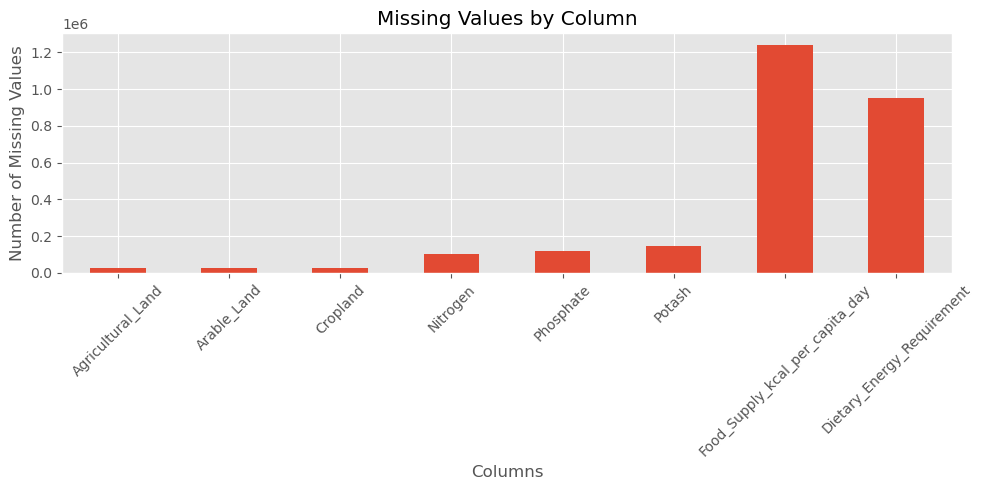

In [185]:
import matplotlib.pyplot as plt

missing_values = final_df.isnull().sum()

missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10,5))
missing_values.plot(kind="bar")
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

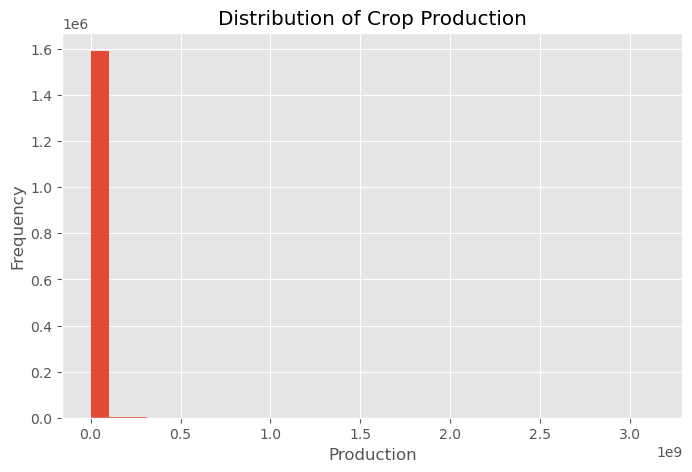

In [187]:
plt.figure(figsize=(8,5))

plt.hist(final_df["Production"], bins=30)

plt.title("Distribution of Crop Production")

plt.xlabel("Production")

plt.ylabel("Frequency")

plt.show()

In [189]:
numeric_df = final_df.select_dtypes(include=["number"])

numeric_df.head()

,Year,Production,Population,Agricultural_Land,Arable_Land,Cropland,Nitrogen,Phosphate,Potash,Food_Supply_kcal_per_capita_day,Dietary_Energy_Requirement
0,1961,0.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN
1,1961,15100.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN
2,1961,32000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN
3,1961,378000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN
4,1961,4104.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN


In [191]:
correlation = numeric_df.corr()

correlation

,Year,Production,Population,Agricultural_Land,Arable_Land,Cropland,Nitrogen,Phosphate,Potash,Food_Supply_kcal_per_capita_day,Dietary_Energy_Requirement
Year,1.000000,0.028627,0.073154,-0.005826,-0.005014,0.002110,0.097678,0.058194,0.056433,0.093850,0.100444
Production,0.028627,1.000000,0.233810,0.212050,0.220114,0.222446,0.238365,0.236895,0.232987,0.013584,0.010582
Population,0.073154,0.233810,1.000000,0.899602,0.915605,0.925399,0.951329,0.932796,0.868823,-0.052941,-0.035694
Agricultural_Land,-0.005826,0.212050,0.899602,1.000000,0.970880,0.972492,0.830368,0.863831,0.836283,-0.036813,-0.046698
Arable_Land,-0.005014,0.220114,0.915605,0.970880,1.000000,0.999346,0.862661,0.895398,0.876223,-0.009040,-0.013113
Cropland,0.002110,0.222446,0.925399,0.972492,0.999346,1.000000,0.872697,0.902552,0.882623,-0.014797,-0.017799
Nitrogen,0.097678,0.238365,0.951329,0.830368,0.862661,0.872697,1.000000,0.981237,0.939157,0.045058,0.045055
Phosphate,0.058194,0.236895,0.932796,0.863831,0.895398,0.902552,0.981237,1.000000,0.972731,0.040328,0.040863
Potash,0.056433,0.232987,0.868823,0.836283,0.876223,0.882623,0.939157,0.972731,1.000000,0.084293,0.064553
Food_Supply_kcal_per_capita_day,0.093850,0.013584,-0.052941,-0.036813,-0.009040,-0.014797,0.045058,0.040328,0.084293,1.000000,0.792372


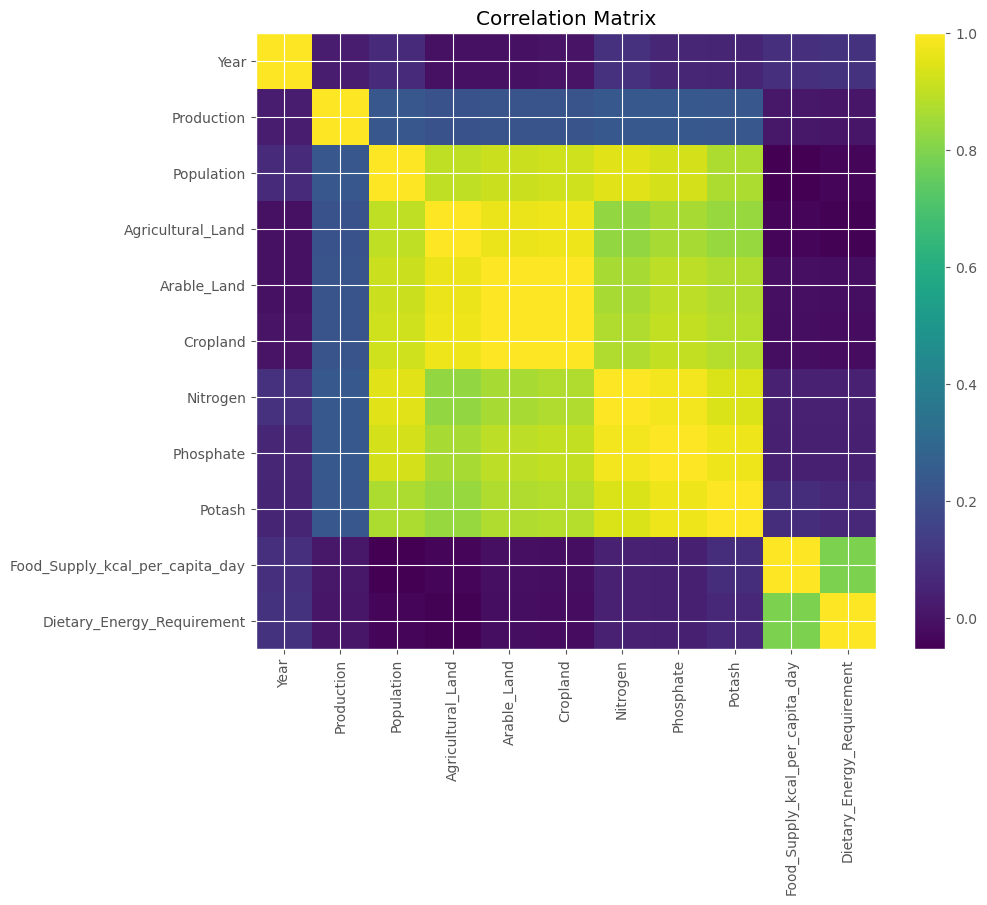

In [193]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.show()

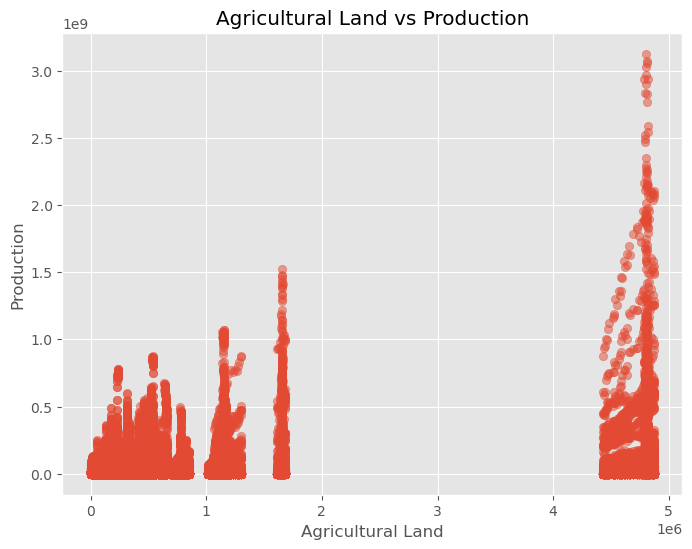

In [195]:
plt.figure(figsize=(8,6))

plt.scatter(
    final_df["Agricultural_Land"],
    final_df["Production"],
    alpha=0.5
)

plt.xlabel("Agricultural Land")

plt.ylabel("Production")

plt.title("Agricultural Land vs Production")

plt.show()

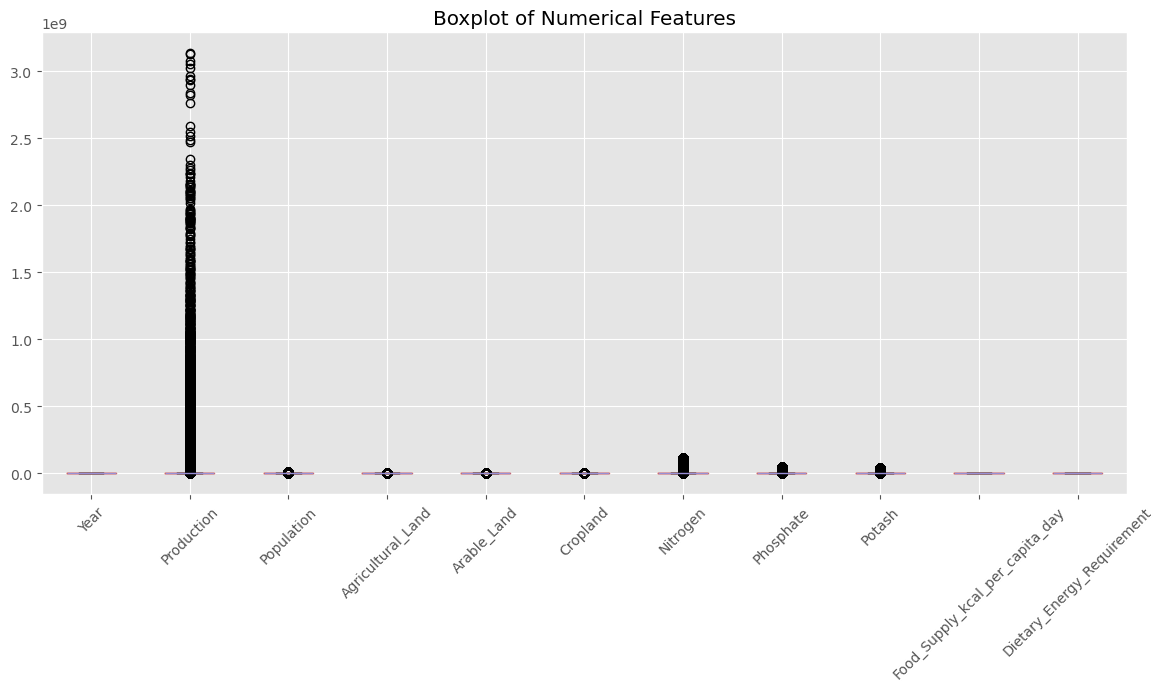

In [196]:
numeric_df.boxplot(
    figsize=(14,6),
    rot=45
)

plt.title("Boxplot of Numerical Features")

plt.show()

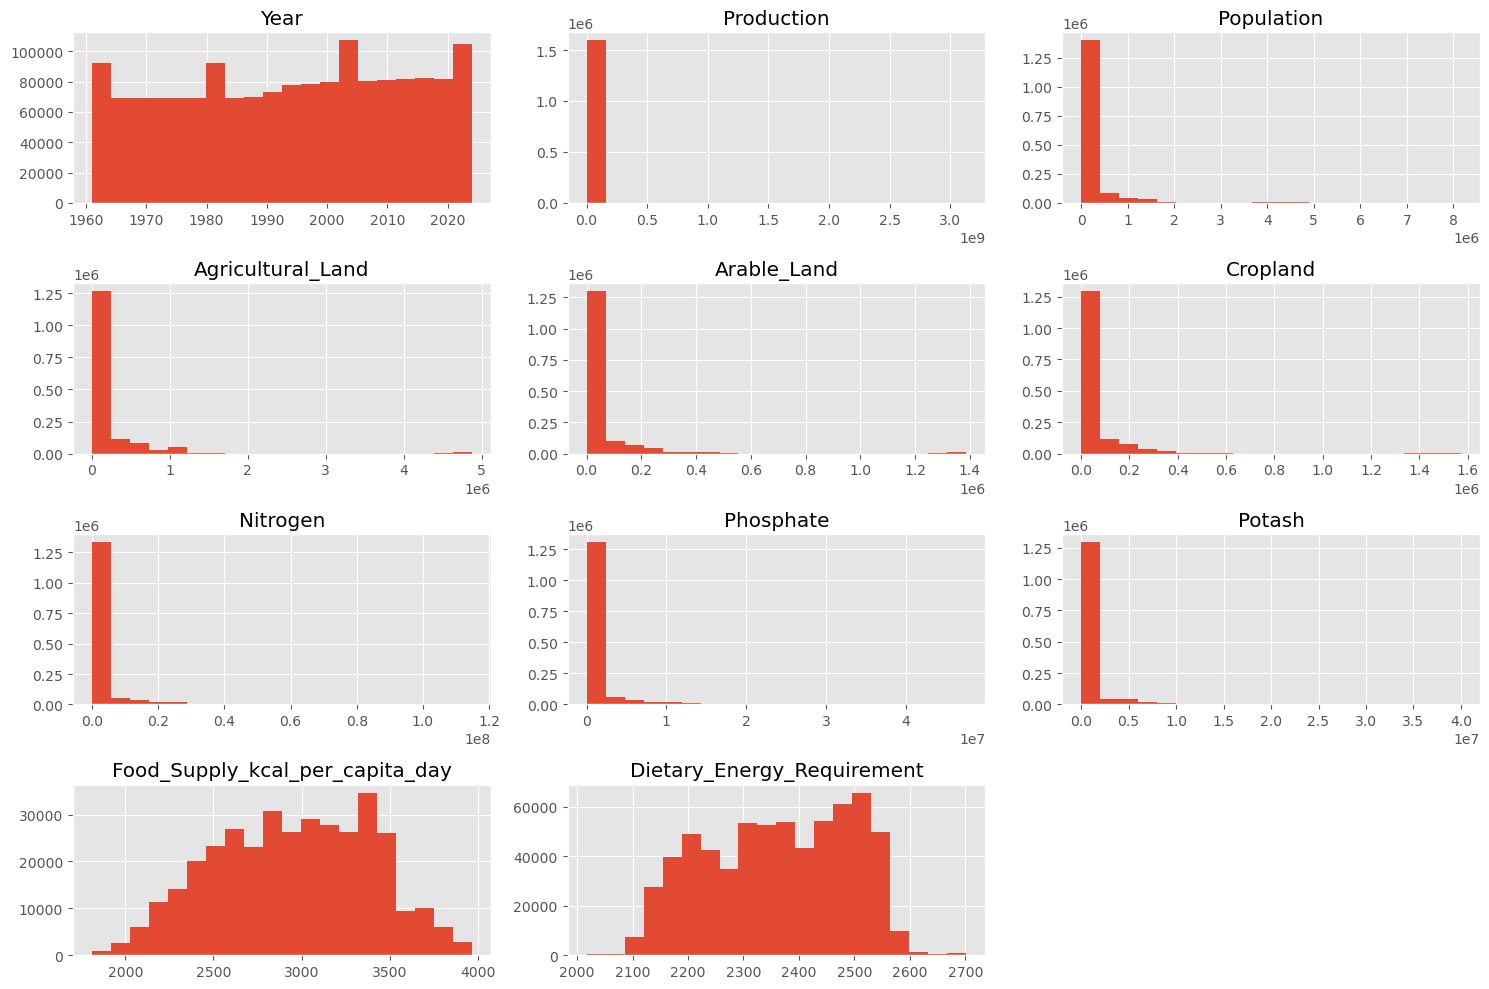

In [199]:
numeric_df.hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()

plt.show()

# Feature Engineering

In [202]:
feature_df = final_df.copy()

print(feature_df.shape)
feature_df.head()

(1598628, 13)


,Area,Item,Year,Production,Population,Agricultural_Land,Arable_Land,Cropland,Nitrogen,Phosphate,Potash,Food_Supply_kcal_per_capita_day,Dietary_Energy_Requirement
0,Afghanistan,"Almonds, in shell",1961,0.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN
1,Afghanistan,Apples,1961,15100.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN
2,Afghanistan,Apricots,1961,32000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN
3,Afghanistan,Barley,1961,378000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN
4,Afghanistan,Butter and ghee of sheep milk,1961,4104.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN


In [204]:
feature_df.select_dtypes(include="number").columns

Index(['Year', 'Production', 'Population', 'Agricultural_Land', 'Arable_Land',
       'Cropland', 'Nitrogen', 'Phosphate', 'Potash',
       'Food_Supply_kcal_per_capita_day', 'Dietary_Energy_Requirement'],
      dtype='object')

In [206]:
feature_df["Production_per_Capita"] = (
    feature_df["Production"] /
    feature_df["Population"]
)

feature_df[
    ["Production", "Population", "Production_per_Capita"]
].head()

,Production,Population,Production_per_Capita
0,0.0,9214.083,0.000000
1,15100.0,9214.083,1.638796
2,32000.0,9214.083,3.472945
3,378000.0,9214.083,41.024158
4,4104.0,9214.083,0.445405


In [208]:
feature_df["Nitrogen_per_Land"] = (
    feature_df["Nitrogen"] /
    feature_df["Agricultural_Land"]
)

feature_df["Phosphate_per_Land"] = (
    feature_df["Phosphate"] /
    feature_df["Agricultural_Land"]
)

feature_df["Potash_per_Land"] = (
    feature_df["Potash"] /
    feature_df["Agricultural_Land"]
)

feature_df.head()

,Area,Item,Year,Production,Population,Agricultural_Land,Arable_Land,Cropland,Nitrogen,Phosphate,Potash,Food_Supply_kcal_per_capita_day,Dietary_Energy_Requirement,Production_per_Capita,Nitrogen_per_Land,Phosphate_per_Land,Potash_per_Land
0,Afghanistan,"Almonds, in shell",1961,0.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,0.000000,0.02649,0.002649,NaN
1,Afghanistan,Apples,1961,15100.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,1.638796,0.02649,0.002649,NaN
2,Afghanistan,Apricots,1961,32000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,3.472945,0.02649,0.002649,NaN
3,Afghanistan,Barley,1961,378000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,41.024158,0.02649,0.002649,NaN
4,Afghanistan,Butter and ghee of sheep milk,1961,4104.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,0.445405,0.02649,0.002649,NaN


In [210]:
feature_df["Arable_Land_Ratio"] = (
    feature_df["Arable_Land"] /
    feature_df["Agricultural_Land"]
)

feature_df.head()

,Area,Item,Year,Production,Population,Agricultural_Land,Arable_Land,Cropland,Nitrogen,Phosphate,Potash,Food_Supply_kcal_per_capita_day,Dietary_Energy_Requirement,Production_per_Capita,Nitrogen_per_Land,Phosphate_per_Land,Potash_per_Land,Arable_Land_Ratio
0,Afghanistan,"Almonds, in shell",1961,0.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,0.000000,0.02649,0.002649,NaN,0.202649
1,Afghanistan,Apples,1961,15100.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,1.638796,0.02649,0.002649,NaN,0.202649
2,Afghanistan,Apricots,1961,32000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,3.472945,0.02649,0.002649,NaN,0.202649
3,Afghanistan,Barley,1961,378000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,41.024158,0.02649,0.002649,NaN,0.202649
4,Afghanistan,Butter and ghee of sheep milk,1961,4104.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,0.445405,0.02649,0.002649,NaN,0.202649


In [212]:
feature_df["Food_Supply_Gap"] = (
    feature_df["Food_Supply_kcal_per_capita_day"] -
    feature_df["Dietary_Energy_Requirement"]
)

feature_df.head()

,Area,Item,Year,Production,Population,Agricultural_Land,Arable_Land,Cropland,Nitrogen,Phosphate,Potash,Food_Supply_kcal_per_capita_day,Dietary_Energy_Requirement,Production_per_Capita,Nitrogen_per_Land,Phosphate_per_Land,Potash_per_Land,Arable_Land_Ratio,Food_Supply_Gap
0,Afghanistan,"Almonds, in shell",1961,0.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,0.000000,0.02649,0.002649,NaN,0.202649,NaN
1,Afghanistan,Apples,1961,15100.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,1.638796,0.02649,0.002649,NaN,0.202649,NaN
2,Afghanistan,Apricots,1961,32000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,3.472945,0.02649,0.002649,NaN,0.202649,NaN
3,Afghanistan,Barley,1961,378000.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,41.024158,0.02649,0.002649,NaN,0.202649,NaN
4,Afghanistan,Butter and ghee of sheep milk,1961,4104.0,9214.083,37750.0,7650.0,7750.0,1000.0,100.0,NaN,NaN,NaN,0.445405,0.02649,0.002649,NaN,0.202649,NaN


In [214]:
import numpy as np

feature_df["Log_Production"] = np.log1p(
    feature_df["Production"]
)

feature_df[
    ["Production", "Log_Production"]
].head()

,Production,Log_Production
0,0.0,0.000000
1,15100.0,9.622516
2,32000.0,10.373522
3,378000.0,12.842652
4,4104.0,8.319961


In [216]:
print(feature_df.shape)

feature_df.info()

feature_df.head()

feature_df.describe()

(1598628, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1598628 entries, 0 to 1598627
Data columns (total 20 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   Area                             1598628 non-null  object 
 1   Item                             1598628 non-null  object 
 2   Year                             1598628 non-null  int32  
 3   Production                       1598628 non-null  float64
 4   Population                       1598628 non-null  float64
 5   Agricultural_Land                1574530 non-null  float64
 6   Arable_Land                      1572112 non-null  float64
 7   Cropland                         1574530 non-null  float64
 8   Nitrogen                         1496907 non-null  float64
 9   Phosphate                        1477519 non-null  float64
 10  Potash                           1453196 non-null  float64
 11  Food_Supply_kcal_per_capita_day  357

,Year,Production,Population,Agricultural_Land,Arable_Land,Cropland,Nitrogen,Phosphate,Potash,Food_Supply_kcal_per_capita_day,Dietary_Energy_Requirement,Production_per_Capita,Nitrogen_per_Land,Phosphate_per_Land,Potash_per_Land,Arable_Land_Ratio,Food_Supply_Gap,Log_Production
count,1.598628e+06,1.598628e+06,1.598628e+06,1.574530e+06,1.572112e+06,1.574530e+06,1.496907e+06,1.477519e+06,1.453196e+06,357835.000000,647327.000000,1.598628e+06,1.496907e+06,1.477519e+06,1.453196e+06,1.572112e+06,347581.000000,1.598628e+06
mean,1.993703e+03,2.674021e+06,2.348929e+05,1.992641e+05,5.451051e+04,5.943599e+04,3.037987e+06,1.369389e+06,1.026042e+06,2953.578095,2363.202536,2.445964e+01,2.777855e+01,1.165489e+01,1.228418e+01,3.741347e-01,574.085854,9.705444e+00
std,1.842113e+01,2.968195e+07,7.403750e+05,5.575451e+05,1.594844e+05,1.737847e+05,1.032552e+07,4.460956e+06,3.418861e+06,442.329498,129.997729,1.561583e+02,5.816999e+01,2.024508e+01,3.611548e+01,2.470378e-01,354.507842,3.799929e+00
min,1.961000e+03,0.000000e+00,1.757000e+00,3.000000e-01,6.400000e-02,6.400000e-02,0.000000e+00,0.000000e+00,-1.770000e+02,1810.450000,2017.000000,0.000000e+00,0.000000e+00,0.000000e+00,-4.962612e-02,5.876476e-04,-476.550000,0.000000e+00
25%,1.978000e+03,1.703000e+03,4.799848e+03,2.360748e+03,8.809000e+02,1.093000e+03,1.629500e+04,6.979000e+03,4.038000e+03,2603.850000,2251.000000,1.263153e-01,2.018053e+00,1.048279e+00,4.298723e-01,1.726130e-01,320.880000,7.440734e+00
50%,1.995000e+03,2.136600e+04,1.964820e+04,1.642780e+04,4.670000e+03,5.358000e+03,1.695830e+05,8.060000e+04,4.886600e+04,2966.340000,2368.000000,1.070997e+00,1.060144e+01,4.595499e+00,2.612385e+00,3.135802e-01,576.820000,9.969603e+00
75%,2.010000e+03,2.166456e+05,1.109570e+05,1.456028e+05,3.199004e+04,3.438150e+04,1.200587e+06,5.703220e+05,3.168150e+05,3318.520000,2484.000000,7.326416e+00,3.712088e+01,1.387112e+01,1.167549e+01,5.575648e-01,846.150000,1.228602e+01
max,2.024000e+03,3.133223e+09,8.161972e+06,4.874032e+06,1.387502e+06,1.571827e+06,1.147846e+08,4.759806e+07,4.000686e+07,3966.570000,2702.000000,9.394426e+03,2.825833e+03,7.166667e+02,2.083333e+03,1.000000e+00,1610.810000,2.186533e+01


In [218]:
feature_df.to_csv(
    "feature_engineered_dataset.csv",
    index=False
)

print("Feature engineered dataset saved successfully!")

Feature engineered dataset saved successfully!


In [220]:
# ==========================================
# Missing Value Summary
# ==========================================

missing_summary = (
    feature_df.isnull()
              .sum()
              .sort_values(ascending=False)
)

print("Missing values in each column:")
print(missing_summary)

missing_percent = (
    feature_df.isnull()
              .mean() * 100
).sort_values(ascending=False)

print("\nPercentage of missing values:")
print(missing_percent.round(2))

Missing values in each column:
Food_Supply_Gap                    1251047
Food_Supply_kcal_per_capita_day    1240793
Dietary_Energy_Requirement          951301
Potash                              145432
Potash_per_Land                     145432
Phosphate                           121109
Phosphate_per_Land                  121109
Nitrogen_per_Land                   101721
Nitrogen                            101721
Arable_Land_Ratio                    26516
Arable_Land                          26516
Agricultural_Land                    24098
Cropland                             24098
Area                                     0
Production_per_Capita                    0
Item                                     0
Population                               0
Production                               0
Year                                     0
Log_Production                           0
dtype: int64

Percentage of missing values:
Food_Supply_Gap                    78.26
Food_Supply_kcal_per_cap

In [222]:
# ==========================================
# Check the year range for each dataset
# ==========================================

print("Production Years")
print(production_clean["Year"].min(), "to", production_clean["Year"].max())

print("\nFood Balance Years")
print(foodbalance_clean["Year"].min(), "to", foodbalance_clean["Year"].max())

print("\nFood Security Years")
print(foodsecurity_clean["Year"].min(), "to", foodsecurity_clean["Year"].max())

print("\nFertilizer Years")
print(fertilizer_clean["Year"].min(), "to", fertilizer_clean["Year"].max())

print("\nLand Use Years")
print(landuse_clean["Year"].min(), "to", landuse_clean["Year"].max())

Production Years
1961 to 2024

Food Balance Years
2010 to 2023

Food Security Years
2000 to 2025

Fertilizer Years
1961 to 2023

Land Use Years
1961 to 2023


# Machine Learning Dataset Preparation

In [225]:
# ==========================================
# Prepare Dataset for Machine Learning
# ==========================================

# Create a copy so the original feature_df remains unchanged
ml_df = feature_df.copy()

# Remove features with very high missing values
ml_df = ml_df.drop(
    columns=[
        "Food_Supply_kcal_per_capita_day",
        "Dietary_Energy_Requirement",
        "Food_Supply_Gap"
    ]
)

print("Remaining columns:")
print(ml_df.columns.tolist())

print("\nShape:")
print(ml_df.shape)

Remaining columns:
['Area', 'Item', 'Year', 'Production', 'Population', 'Agricultural_Land', 'Arable_Land', 'Cropland', 'Nitrogen', 'Phosphate', 'Potash', 'Production_per_Capita', 'Nitrogen_per_Land', 'Phosphate_per_Land', 'Potash_per_Land', 'Arable_Land_Ratio', 'Log_Production']

Shape:
(1598628, 17)


# Machine Learning Preprocessing

In [235]:
# ==========================================
# Create Features (X) and Target (y)
# ==========================================



# X = feature_df.drop(
#     columns=[
#         "Area",
#         "Item",
#         "Production",
#         "Log_Production"
#     ]
# )

# y = feature_df["Production"]

X = ml_df.drop(
    columns=[
        "Area",
        "Item",
        "Production",
        "Log_Production",
        "Production_per_Capita"
    ]
)

y = ml_df["Production"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nMissing Values Before Imputation:")
print(X.isnull().sum())

Features Shape: (1598628, 12)
Target Shape: (1598628,)

Missing Values Before Imputation:
Year                       0
Population                 0
Agricultural_Land      24098
Arable_Land            26516
Cropland               24098
Nitrogen              101721
Phosphate             121109
Potash                145432
Nitrogen_per_Land     101721
Phosphate_per_Land    121109
Potash_per_Land       145432
Arable_Land_Ratio      26516
dtype: int64


In [237]:
# ==========================================
# Fill Remaining Missing Values
# ==========================================

print("Missing values BEFORE imputation:")
print(X.isnull().sum())

# Fill numeric columns with the median
X = X.fillna(X.median(numeric_only=True))

print("\nMissing values AFTER imputation:")
print(X.isnull().sum())

Missing values BEFORE imputation:
Year                       0
Population                 0
Agricultural_Land      24098
Arable_Land            26516
Cropland               24098
Nitrogen              101721
Phosphate             121109
Potash                145432
Nitrogen_per_Land     101721
Phosphate_per_Land    121109
Potash_per_Land       145432
Arable_Land_Ratio      26516
dtype: int64

Missing values AFTER imputation:
Year                  0
Population            0
Agricultural_Land     0
Arable_Land           0
Cropland              0
Nitrogen              0
Phosphate             0
Potash                0
Nitrogen_per_Land     0
Phosphate_per_Land    0
Potash_per_Land       0
Arable_Land_Ratio     0
dtype: int64


In [239]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1278902, 12)
(319726, 12)


In [241]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [243]:
import numpy as np

# Count infinite values in each numeric column
inf_counts = np.isinf(X).sum()

print(inf_counts)

Year                  0
Population            0
Agricultural_Land     0
Arable_Land           0
Cropland              0
Nitrogen              0
Phosphate             0
Potash                0
Nitrogen_per_Land     0
Phosphate_per_Land    0
Potash_per_Land       0
Arable_Land_Ratio     0
dtype: int64


In [245]:
for col in X.columns:
    if np.isinf(X[col]).sum() > 0:
        print(col, np.isinf(X[col]).sum())

In [249]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [251]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


In [253]:
missing = X.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


In [255]:
print("Total missing values:", X.isnull().sum().sum())

Total missing values: 0


In [257]:
print(X.isnull().sum().sum())

0


In [259]:
print(final_df.shape)

(1598628, 13)


In [261]:
print(final_df.head())

          Area                           Item  Year  Production  Population  \
0  Afghanistan              Almonds, in shell  1961         0.0    9214.083   
1  Afghanistan                         Apples  1961     15100.0    9214.083   
2  Afghanistan                       Apricots  1961     32000.0    9214.083   
3  Afghanistan                         Barley  1961    378000.0    9214.083   
4  Afghanistan  Butter and ghee of sheep milk  1961      4104.0    9214.083   

   Agricultural_Land  Arable_Land  Cropland  Nitrogen  Phosphate  Potash  \
0            37750.0       7650.0    7750.0    1000.0      100.0     NaN   
1            37750.0       7650.0    7750.0    1000.0      100.0     NaN   
2            37750.0       7650.0    7750.0    1000.0      100.0     NaN   
3            37750.0       7650.0    7750.0    1000.0      100.0     NaN   
4            37750.0       7650.0    7750.0    1000.0      100.0     NaN   

   Food_Supply_kcal_per_capita_day  Dietary_Energy_Requirement  
0  

In [263]:
print(final_df.columns)

Index(['Area', 'Item', 'Year', 'Production', 'Population', 'Agricultural_Land',
       'Arable_Land', 'Cropland', 'Nitrogen', 'Phosphate', 'Potash',
       'Food_Supply_kcal_per_capita_day', 'Dietary_Energy_Requirement'],
      dtype='object')


In [265]:
print(production_clean.shape)
print(population_clean.shape)
print(landuse_clean.shape)
print(fertilizer_clean.shape)
print(foodbalance_clean.shape)
print(foodsecurity_clean.shape)
print(final_df.shape)

(1598628, 4)
(38973, 3)
(15804, 5)
(12628, 5)
(2982, 3)
(6266, 3)
(1598628, 13)


# Linear Regression Model

In [268]:
# ===========================================
# Linear Regression Model
# ===========================================

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [270]:
# ===========================================
# Predictions
# ===========================================

y_pred_lr = lr_model.predict(X_test_scaled)

print("Predictions generated successfully!")

Predictions generated successfully!


In [329]:
# ===========================================
# Linear Regression Evaluation
# ===========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lr_mae = mean_absolute_error(y_test, y_pred_lr)

lr_mse = mean_squared_error(y_test, y_pred_lr)

lr_rmse = lr_mse ** 0.5

lr_r2 = r2_score(y_test, y_pred_lr)

print(f"MAE : {lr_mae:,.2f}")
print(f"MSE : {lr_mse:,.2f}")
print(f"RMSE: {lr_rmse:,.2f}")
print(f"R²  : {lr_r2:.4f}")

MAE : 4,084,985.80
MSE : 832,921,076,659,224.88
RMSE: 28,860,372.08
R²  : 0.0637


In [331]:
comparison = (
    pd.DataFrame({
        "Actual": y_test.values,
        "Predicted": y_pred_lr
    })
)

comparison.head(10)

,Actual,Predicted
0,308800.00,9.178624e+05
1,147839.84,-8.968640e+04
2,269710.00,1.749969e+06
3,128261.00,4.137366e+05
4,84000.00,1.090668e+06
5,20840.00,3.616291e+05
6,155137.00,9.921548e+05
7,129133.00,6.226301e+05
8,0.00,1.877009e+05
9,8000.00,4.461856e+05


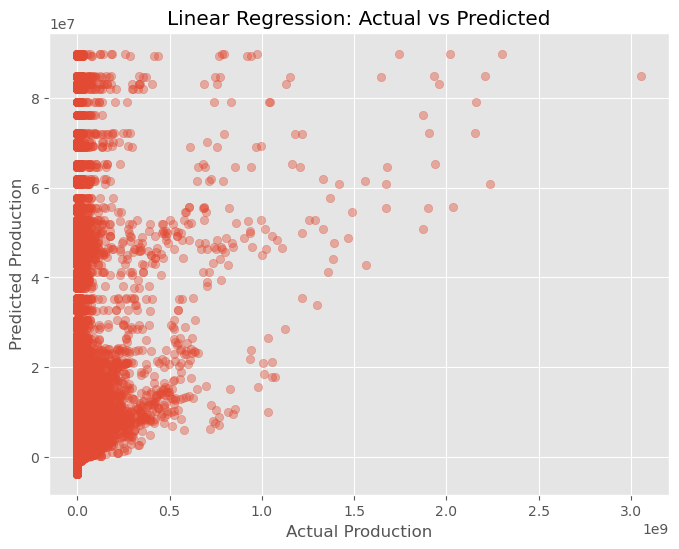

In [333]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.4
)

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

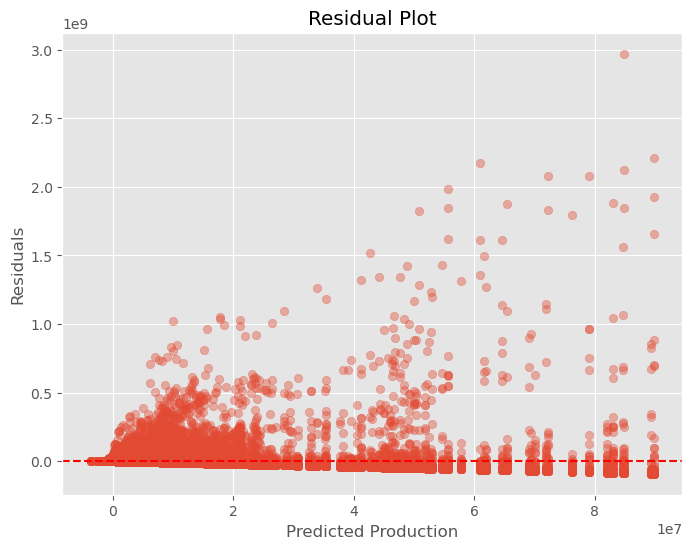

In [335]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_lr,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Production")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

# Decision Tree Regressor

In [293]:
# ===========================================
# Decision Tree Regressor
# ===========================================

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=20,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [295]:
# ===========================================
# Predictions
# ===========================================

y_pred_dt = dt_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [337]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

dt_mae = mean_absolute_error(y_test, y_pred_dt)

dt_mse = mean_squared_error(y_test, y_pred_dt)

dt_rmse = dt_mse ** 0.5

dt_r2 = r2_score(y_test, y_pred_dt)

print(f"MAE : {dt_mae:,.2f}")
print(f"MSE : {dt_mse:,.2f}")
print(f"RMSE: {dt_rmse:,.2f}")
print(f"R²  : {dt_r2:.4f}")

MAE : 4,044,786.56
MSE : 838,532,626,361,353.88
RMSE: 28,957,427.83
R²  : 0.0574


In [339]:
comparison_dt = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_dt
})

comparison_dt.head(10)

,Actual,Predicted
0,308800.00,1.097194e+05
1,147839.84,1.072030e+06
2,269710.00,3.670599e+06
3,128261.00,3.163228e+05
4,84000.00,5.796565e+06
5,20840.00,1.198976e+05
6,155137.00,3.810051e+05
7,129133.00,5.743212e+04
8,0.00,2.023441e+03
9,8000.00,1.317390e+05


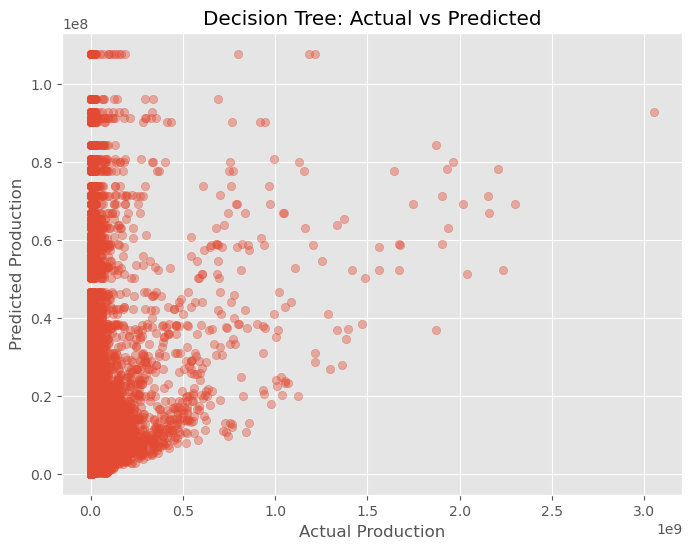

In [341]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_dt,
    alpha=0.4
)

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

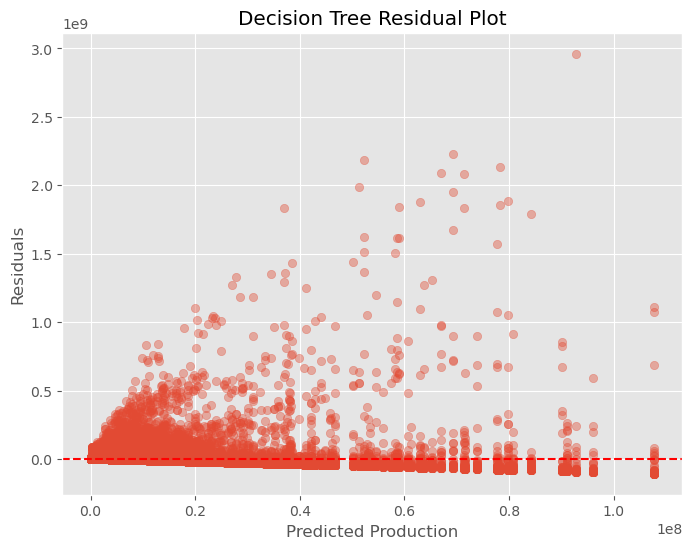

In [342]:
residuals = y_test - y_pred_dt

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_dt,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Production")
plt.ylabel("Residuals")
plt.title("Decision Tree Residual Plot")

plt.show()

# Random Forest Regressor

In [306]:
# ===========================================
# Random Forest Regressor
# ===========================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [308]:
# ===========================================
# Predictions
# ===========================================

y_pred_rf = rf_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [346]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_mse = mean_squared_error(y_test, y_pred_rf)

rf_rmse = rf_mse ** 0.5

rf_r2 = r2_score(y_test, y_pred_rf)

print(f"MAE : {rf_mae:,.2f}")
print(f"MSE : {rf_mse:,.2f}")
print(f"RMSE: {rf_rmse:,.2f}")
print(f"R²  : {rf_r2:.4f}")

MAE : 4,045,803.82
MSE : 838,519,320,461,349.38
RMSE: 28,957,198.08
R²  : 0.0574


In [348]:
comparison_rf = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

comparison_rf.head(10)

,Actual,Predicted
0,308800.00,1.056569e+05
1,147839.84,1.105786e+06
2,269710.00,3.657890e+06
3,128261.00,2.871005e+05
4,84000.00,5.560205e+06
5,20840.00,1.189925e+05
6,155137.00,3.665130e+05
7,129133.00,5.727487e+04
8,0.00,1.999609e+03
9,8000.00,1.317558e+05


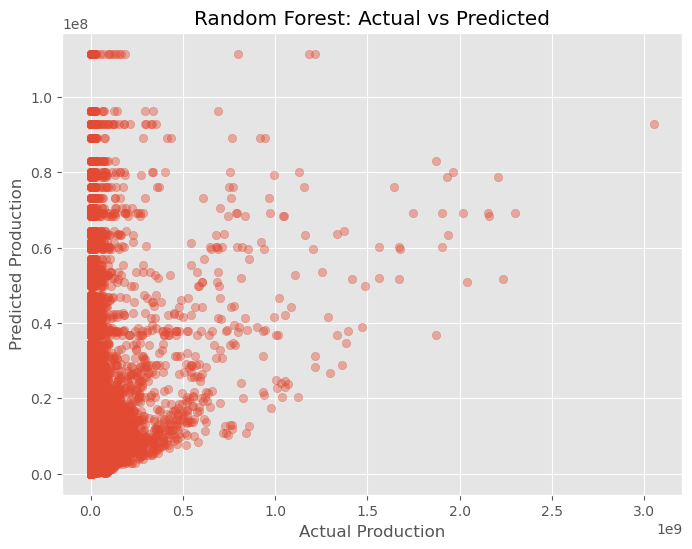

In [350]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.4
)

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

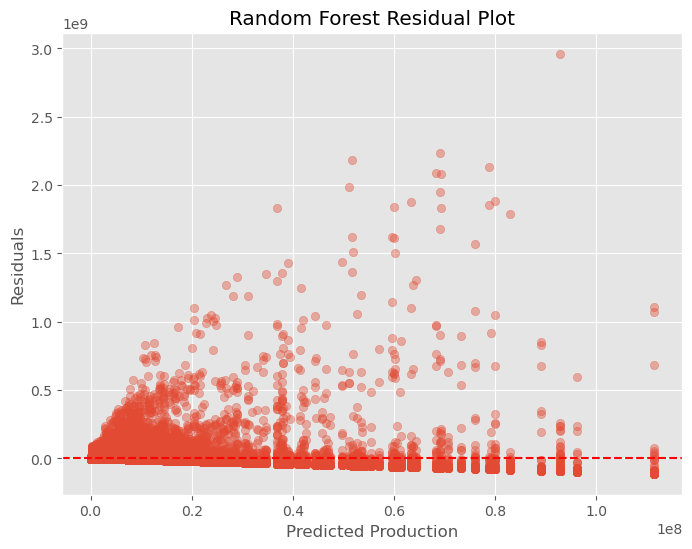

In [351]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_rf,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Production")
plt.ylabel("Residuals")
plt.title("Random Forest Residual Plot")

plt.show()

In [354]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Population,0.674600
6,Phosphate,0.205417
5,Nitrogen,0.024822
0,Year,0.015564
11,Arable_Land_Ratio,0.013209
3,Arable_Land,0.012529
7,Potash,0.012523
2,Agricultural_Land,0.012036
4,Cropland,0.009983
9,Phosphate_per_Land,0.007560


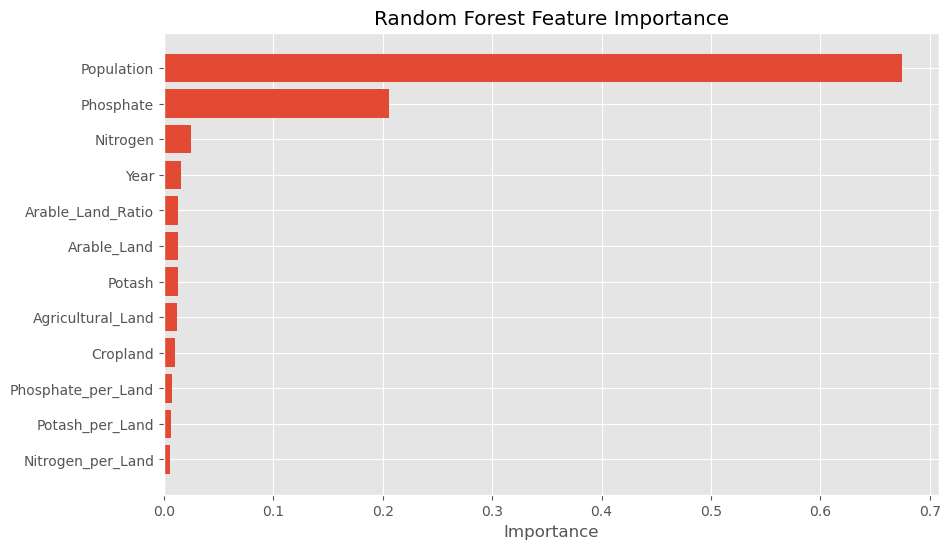

In [356]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.show()

In [358]:
import joblib

joblib.dump(rf_model, "random_forest_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


## XGBoost Regressor

In [372]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [374]:
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [376]:
y_pred_xgb = xgb_model.predict(X_test)

In [378]:
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print(f"MAE : {xgb_mae:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"R²  : {xgb_r2:.4f}")

XGBoost Performance
MAE : 4032441.5072
RMSE: 28938300.1915
R²  : 0.0586


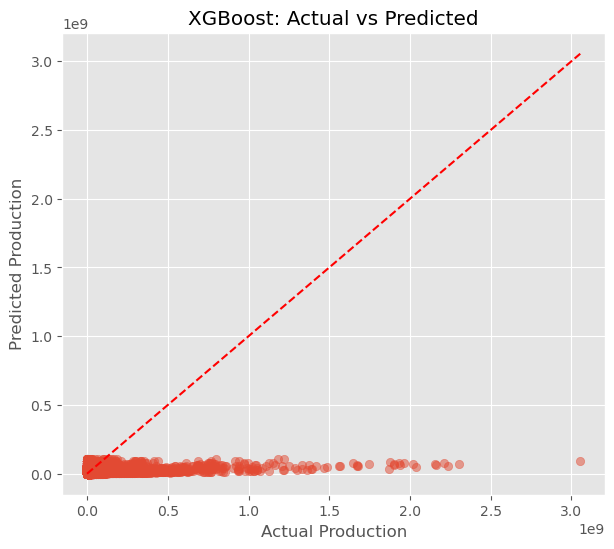

In [380]:
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred_xgb,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("XGBoost: Actual vs Predicted")

plt.show()

In [382]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,Population,0.296081
6,Phosphate,0.223325
5,Nitrogen,0.123822
2,Agricultural_Land,0.111195
4,Cropland,0.081855
7,Potash,0.043272
10,Potash_per_Land,0.022468
8,Nitrogen_per_Land,0.021181
9,Phosphate_per_Land,0.020131
3,Arable_Land,0.019811


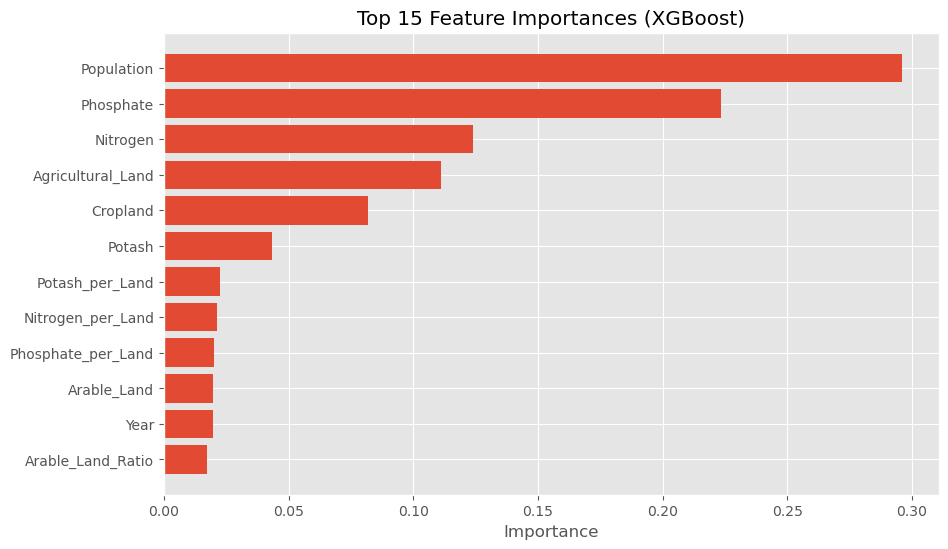

In [384]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance")

plt.show()

# Model Comparison

In [389]:
# ===========================================
# Compare All Models
# ===========================================

comparison = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R²":[
        lr_r2,
        dt_r2,
        rf_r2,
        xgb_r2
    ]
})

comparison.sort_values(
    by="R²",
    ascending=False
)

,Model,MAE,RMSE,R²
0,Linear Regression,4.084986e+06,2.886037e+07,0.063709
3,XGBoost,4.032442e+06,2.893830e+07,0.058646
2,Random Forest,4.045804e+06,2.895720e+07,0.057416
1,Decision Tree,4.044787e+06,2.895743e+07,0.057401


In [391]:
best_model = results.iloc[0]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model    Linear Regression
MAE         4084985.802419
RMSE       28860372.081095
R²                0.063709
Name: 0, dtype: object


In [393]:
import joblib

joblib.dump(rf_model, "best_crop_production_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [395]:
feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    "feature_names.pkl"
)

print("Feature names saved successfully!")

Feature names saved successfully!
